<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Wall_Power_Comparison_of_Quantum_Computing_vs_HPC_vs_Data_Centers_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install pylint

------------------------------------
Your code has been rated at 10.00/10
--------------------------------------------------------------------
Your code has been rated at 10.00/10 (previous run: 10.00/10, +0.00)
Pylint attribute self-check: passed
Pylint argument and name self-check: passed
Matplotlib and Plotly API preflight: passed
Current quantum-system electrical power anchors


,System,Architecture,Physical_qubits,Reported_power_MW,Power_basis,Reference
0,Google Sycamore,Gate-model superconducting,53,0.0260,Apparatus average estimate,"Arute et al. (2019), Supplementary Information"
1,IQM Radiance,Gate-model superconducting,54,0.0260,Typical mean total electrical power,IQM Radiance product specification
2,D-Wave Advantage,Quantum annealing,"5,000",0.0250,Maximum rated electrical power,D-Wave Advantage datasheet v10



Published FTQC scenarios with full-wall model


,Scenario,Active_logical_qubits,Physical_per_logical,Redundancy_factor,Quantum_side_power_MW,Published_W_per_physical_qubit,Facility_physical_qubits,QEC_decoder_power_MW,Classical_host_power_MW,Estimated_full_wall_power_MW,Full_wall_W_per_physical_qubit,Quantum_side_W_per_active_logical_qubit,Full_wall_W_per_active_logical_qubit
0,Practical FTQC,200,500,2,12.00,59.700,"200,000",0.02,2.00,14.02,70.100,"60,000.0","70,100.0"
1,Small Full FTQC,"2,000","1,000",2,27.00,6.800,"4,000,000",0.40,2.00,29.40,7.350,"13,500.0","14,700.0"
2,Large Full FTQC,"5,000","2,000",2,4.00,0.200,"20,000,000",2.00,2.00,8.00,0.400,800.0,"1,600.0"



June 2026 TOP500 power with facility-wall normalization


,System,TOP500_rank_June_2026,Reported_machine_power_MW,Estimated_facility_wall_MW,Estimated_PUE_overhead_MW
0,LineShine,1,42.220,50.664,8.444
1,El Capitan,2,29.685,35.622,5.937
2,Frontier,3,24.607,29.528,4.921
3,Aurora,4,38.698,46.438,7.740
4,JUPITER Booster,5,15.794,18.953,3.159



U.S. data-center electricity and average-power equivalent


,Year,Scenario,US_data_center_TWh_per_year,Average_power_GW
0,2014,Historical,58,6.62
1,2023,Historical,176,20.09
2,2028,Projection low,325,37.10
3,2028,Projection high,580,66.21


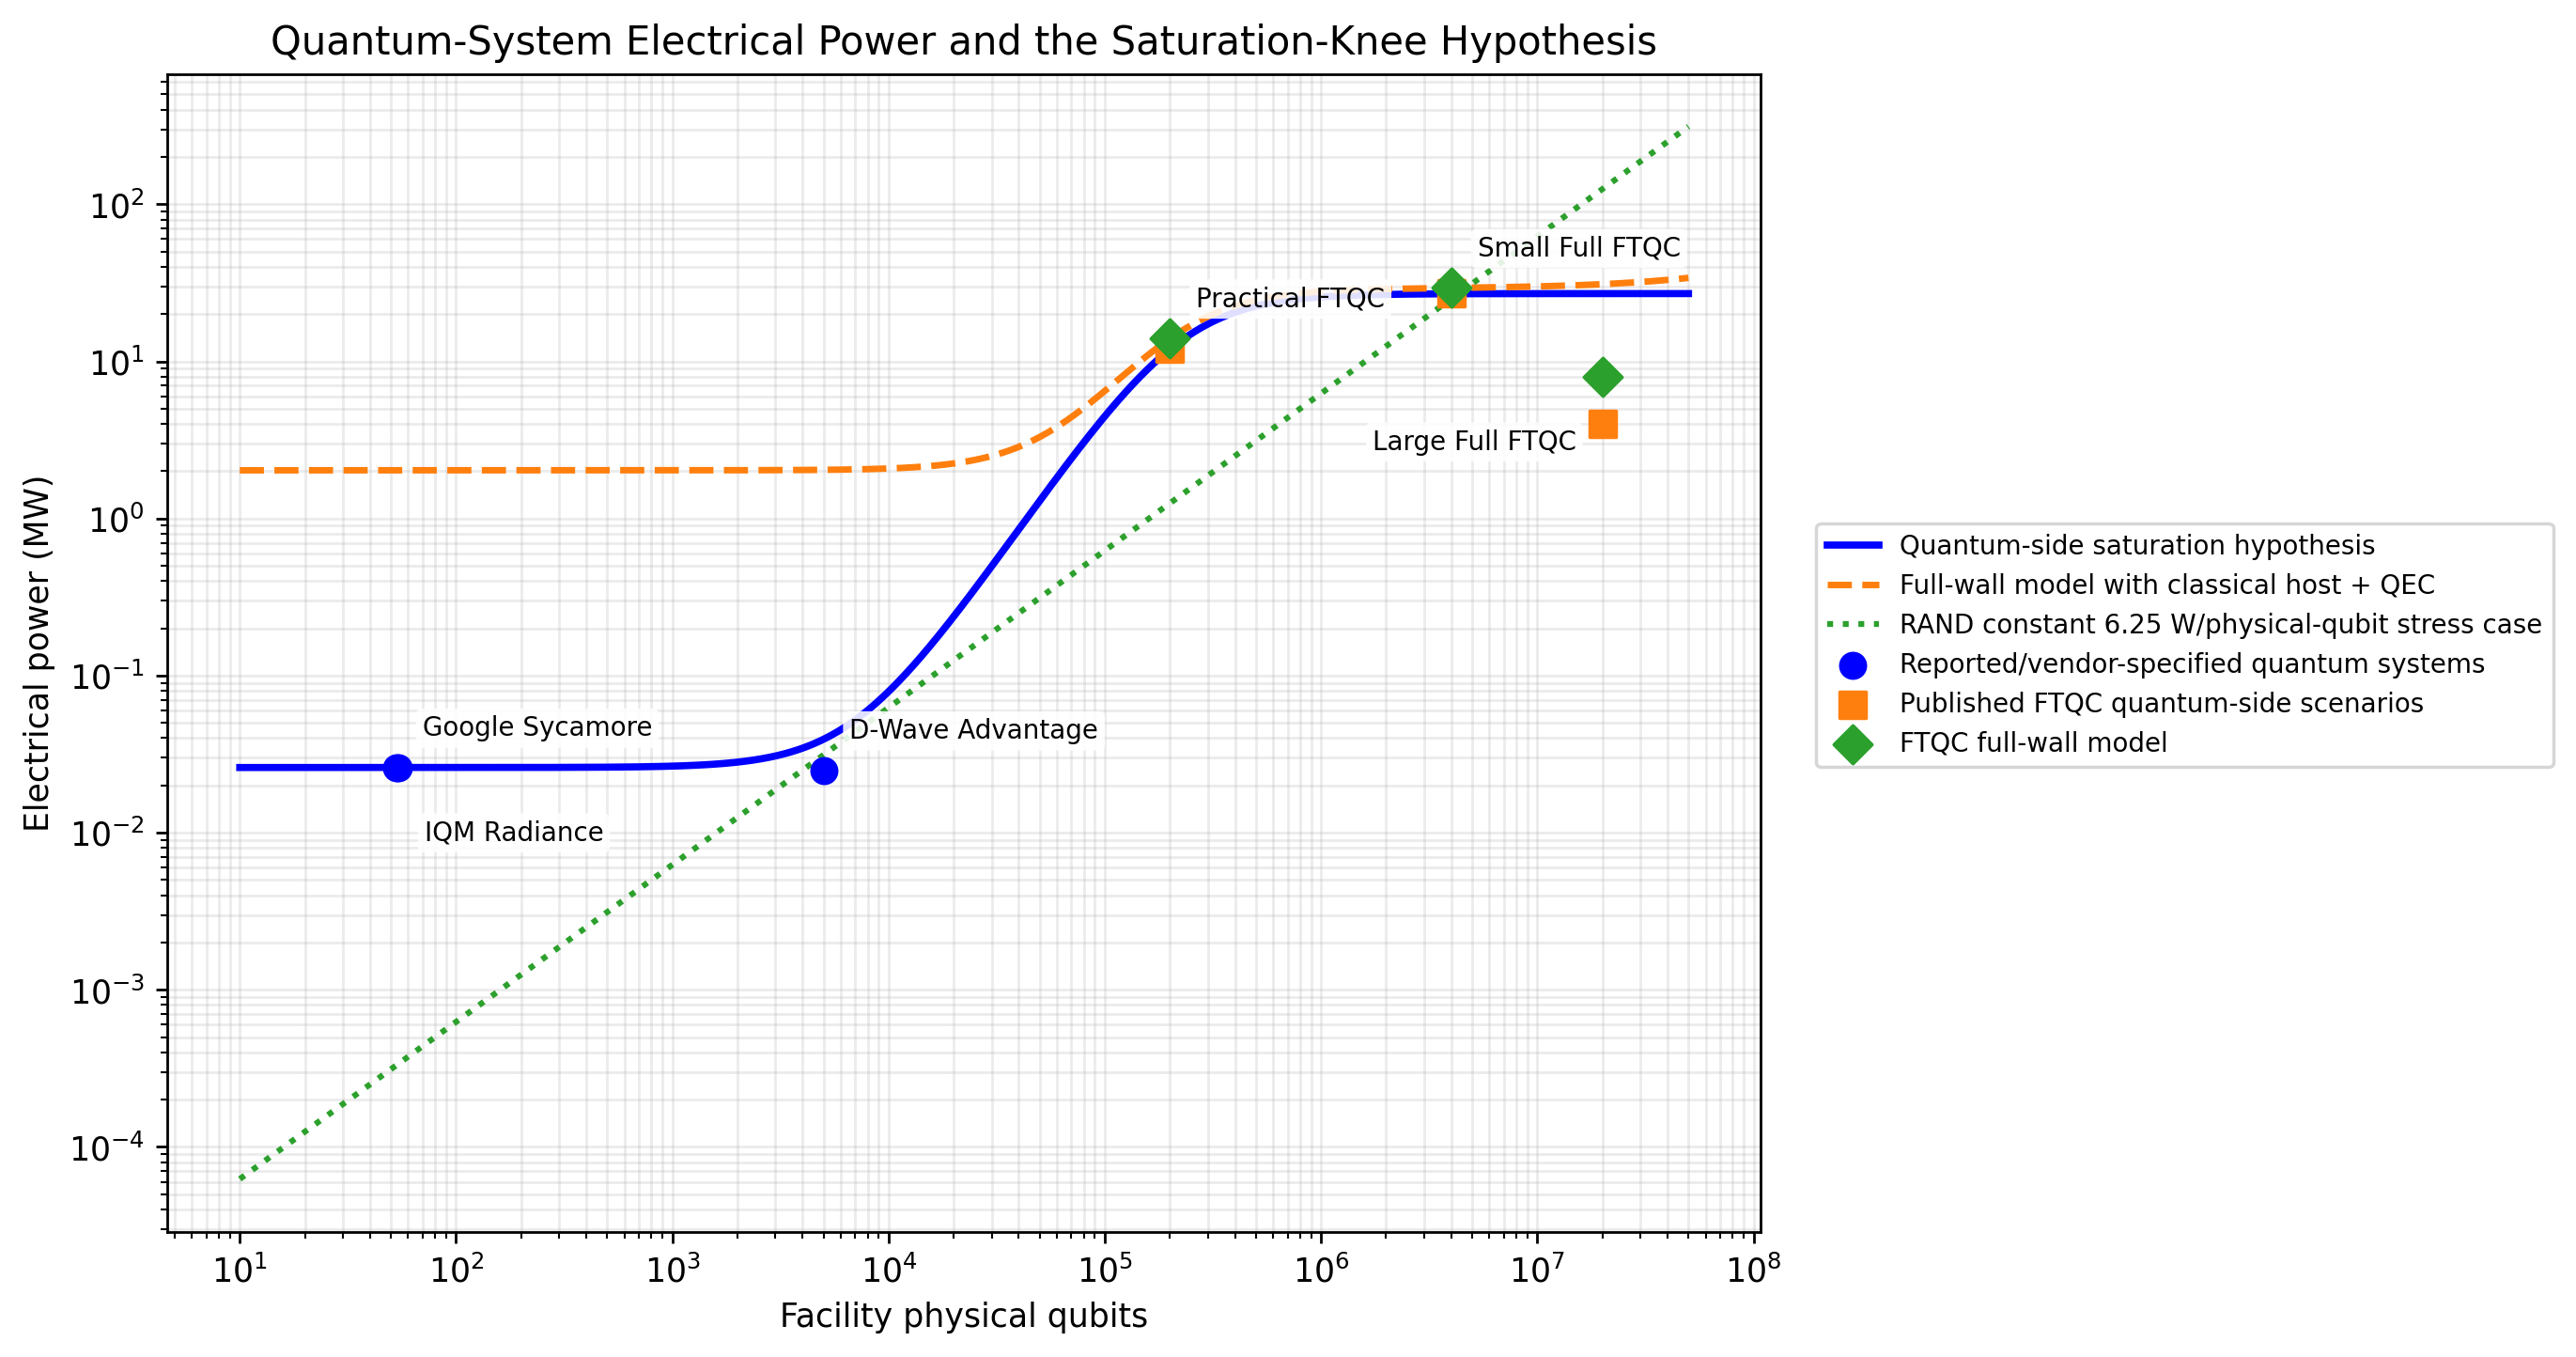

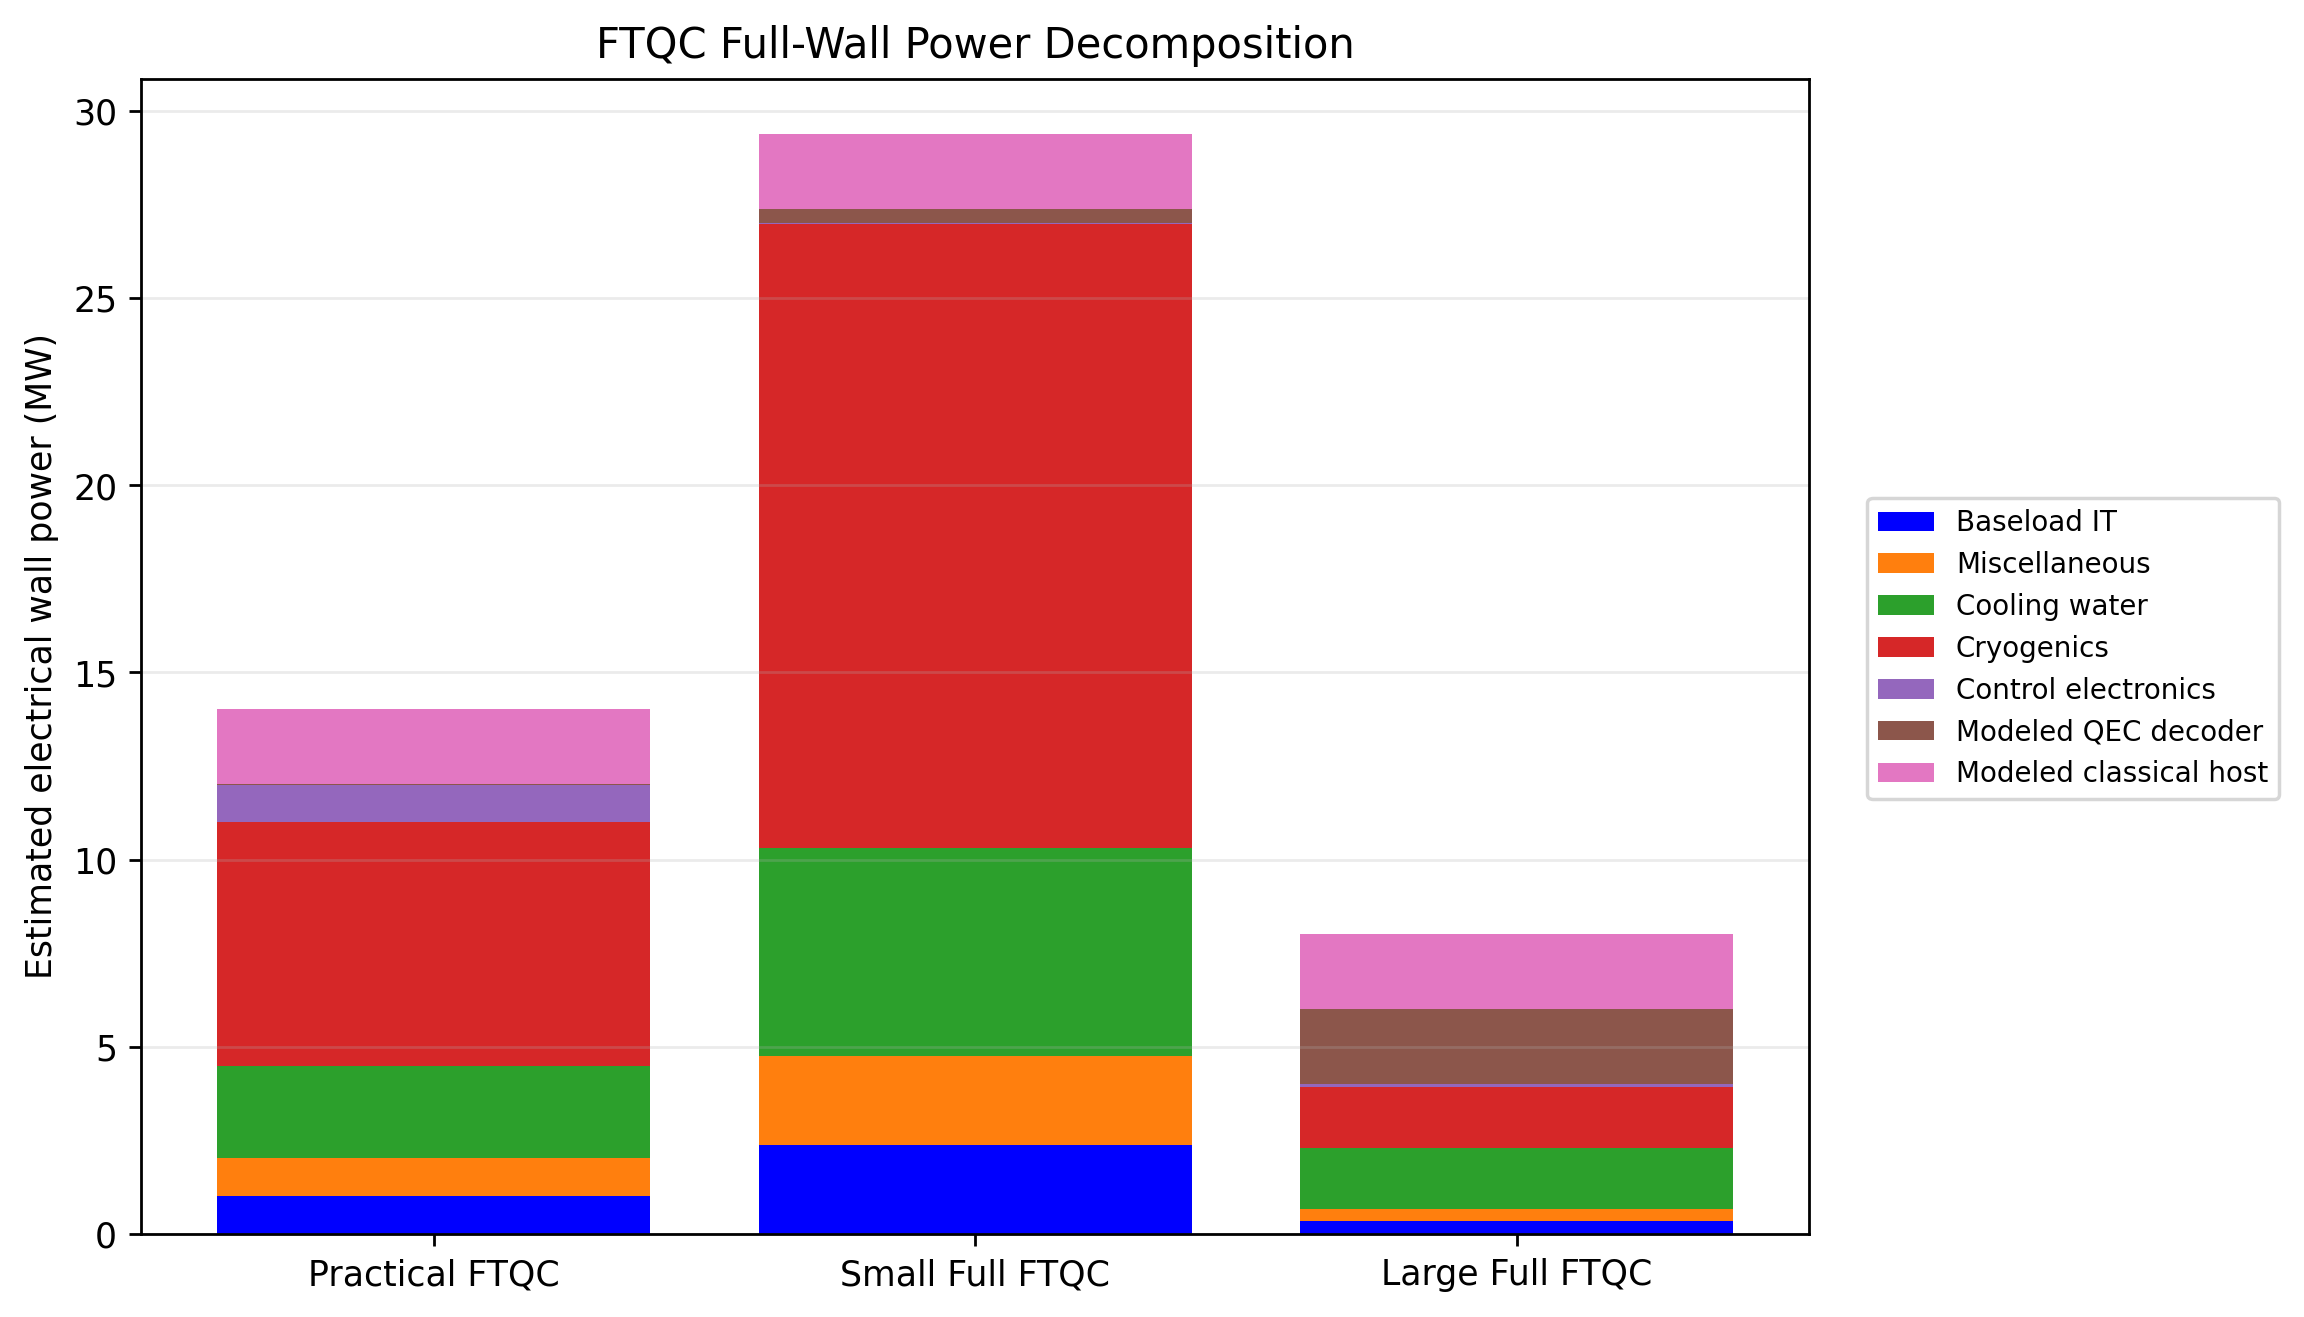

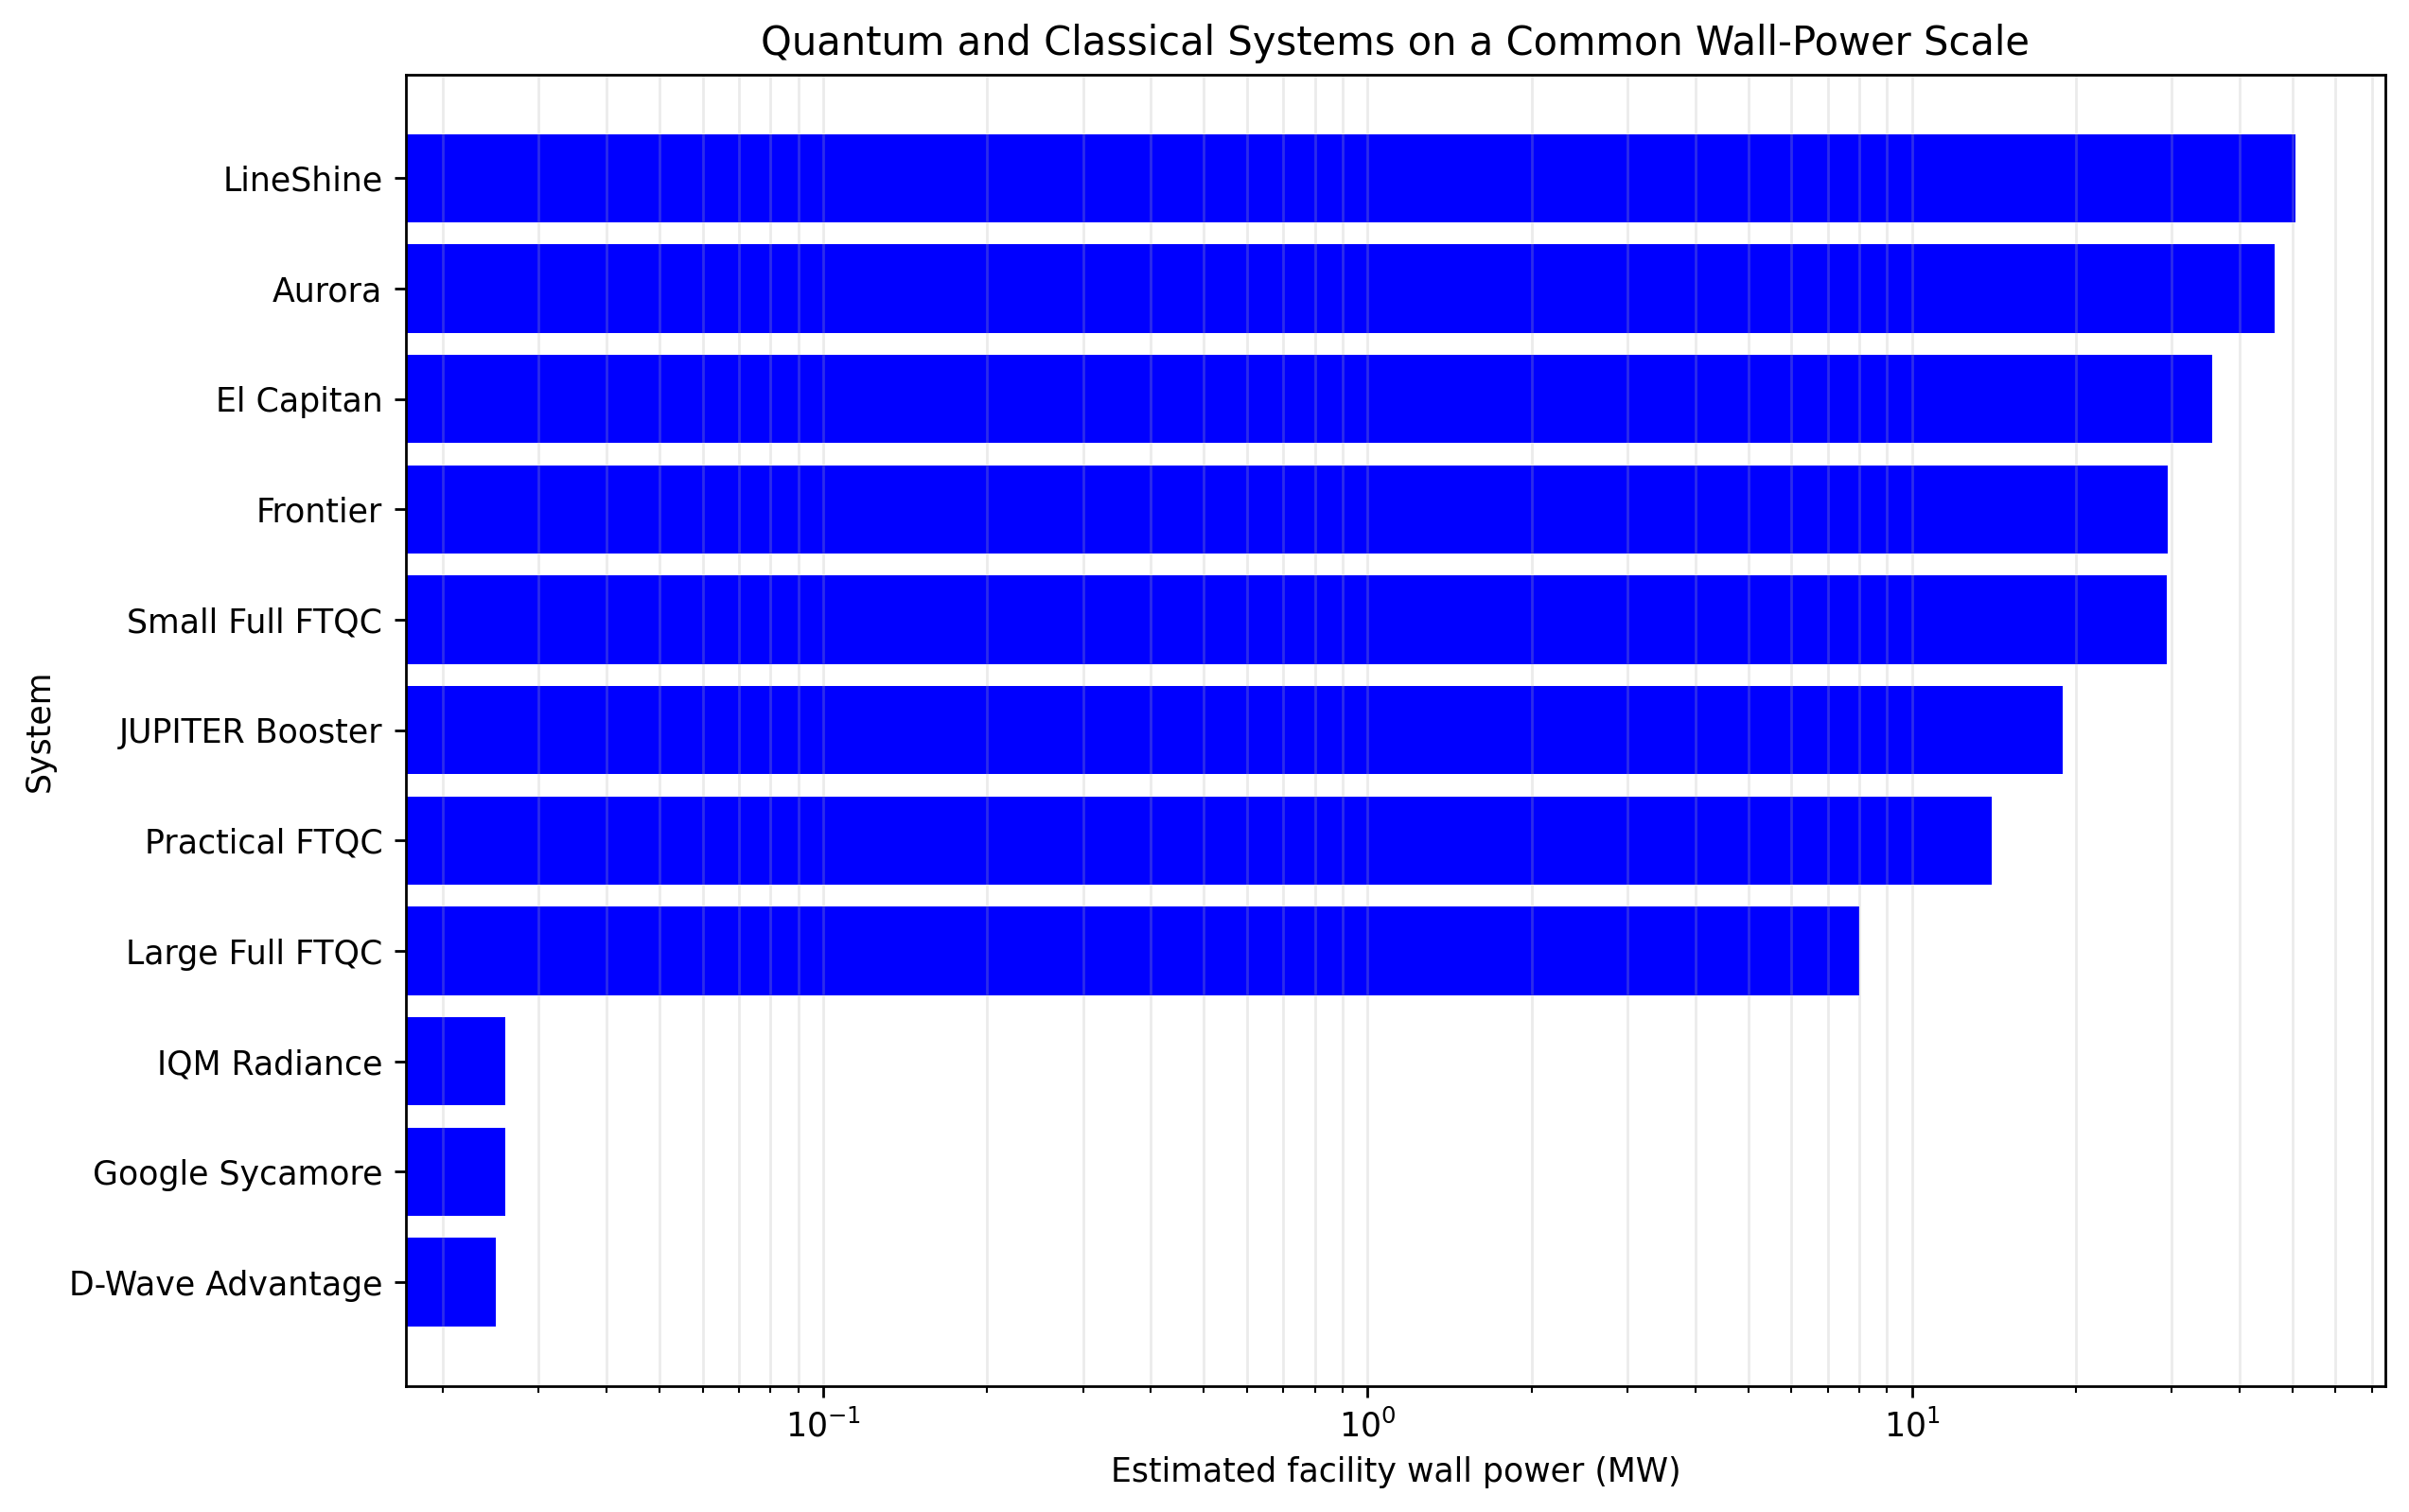

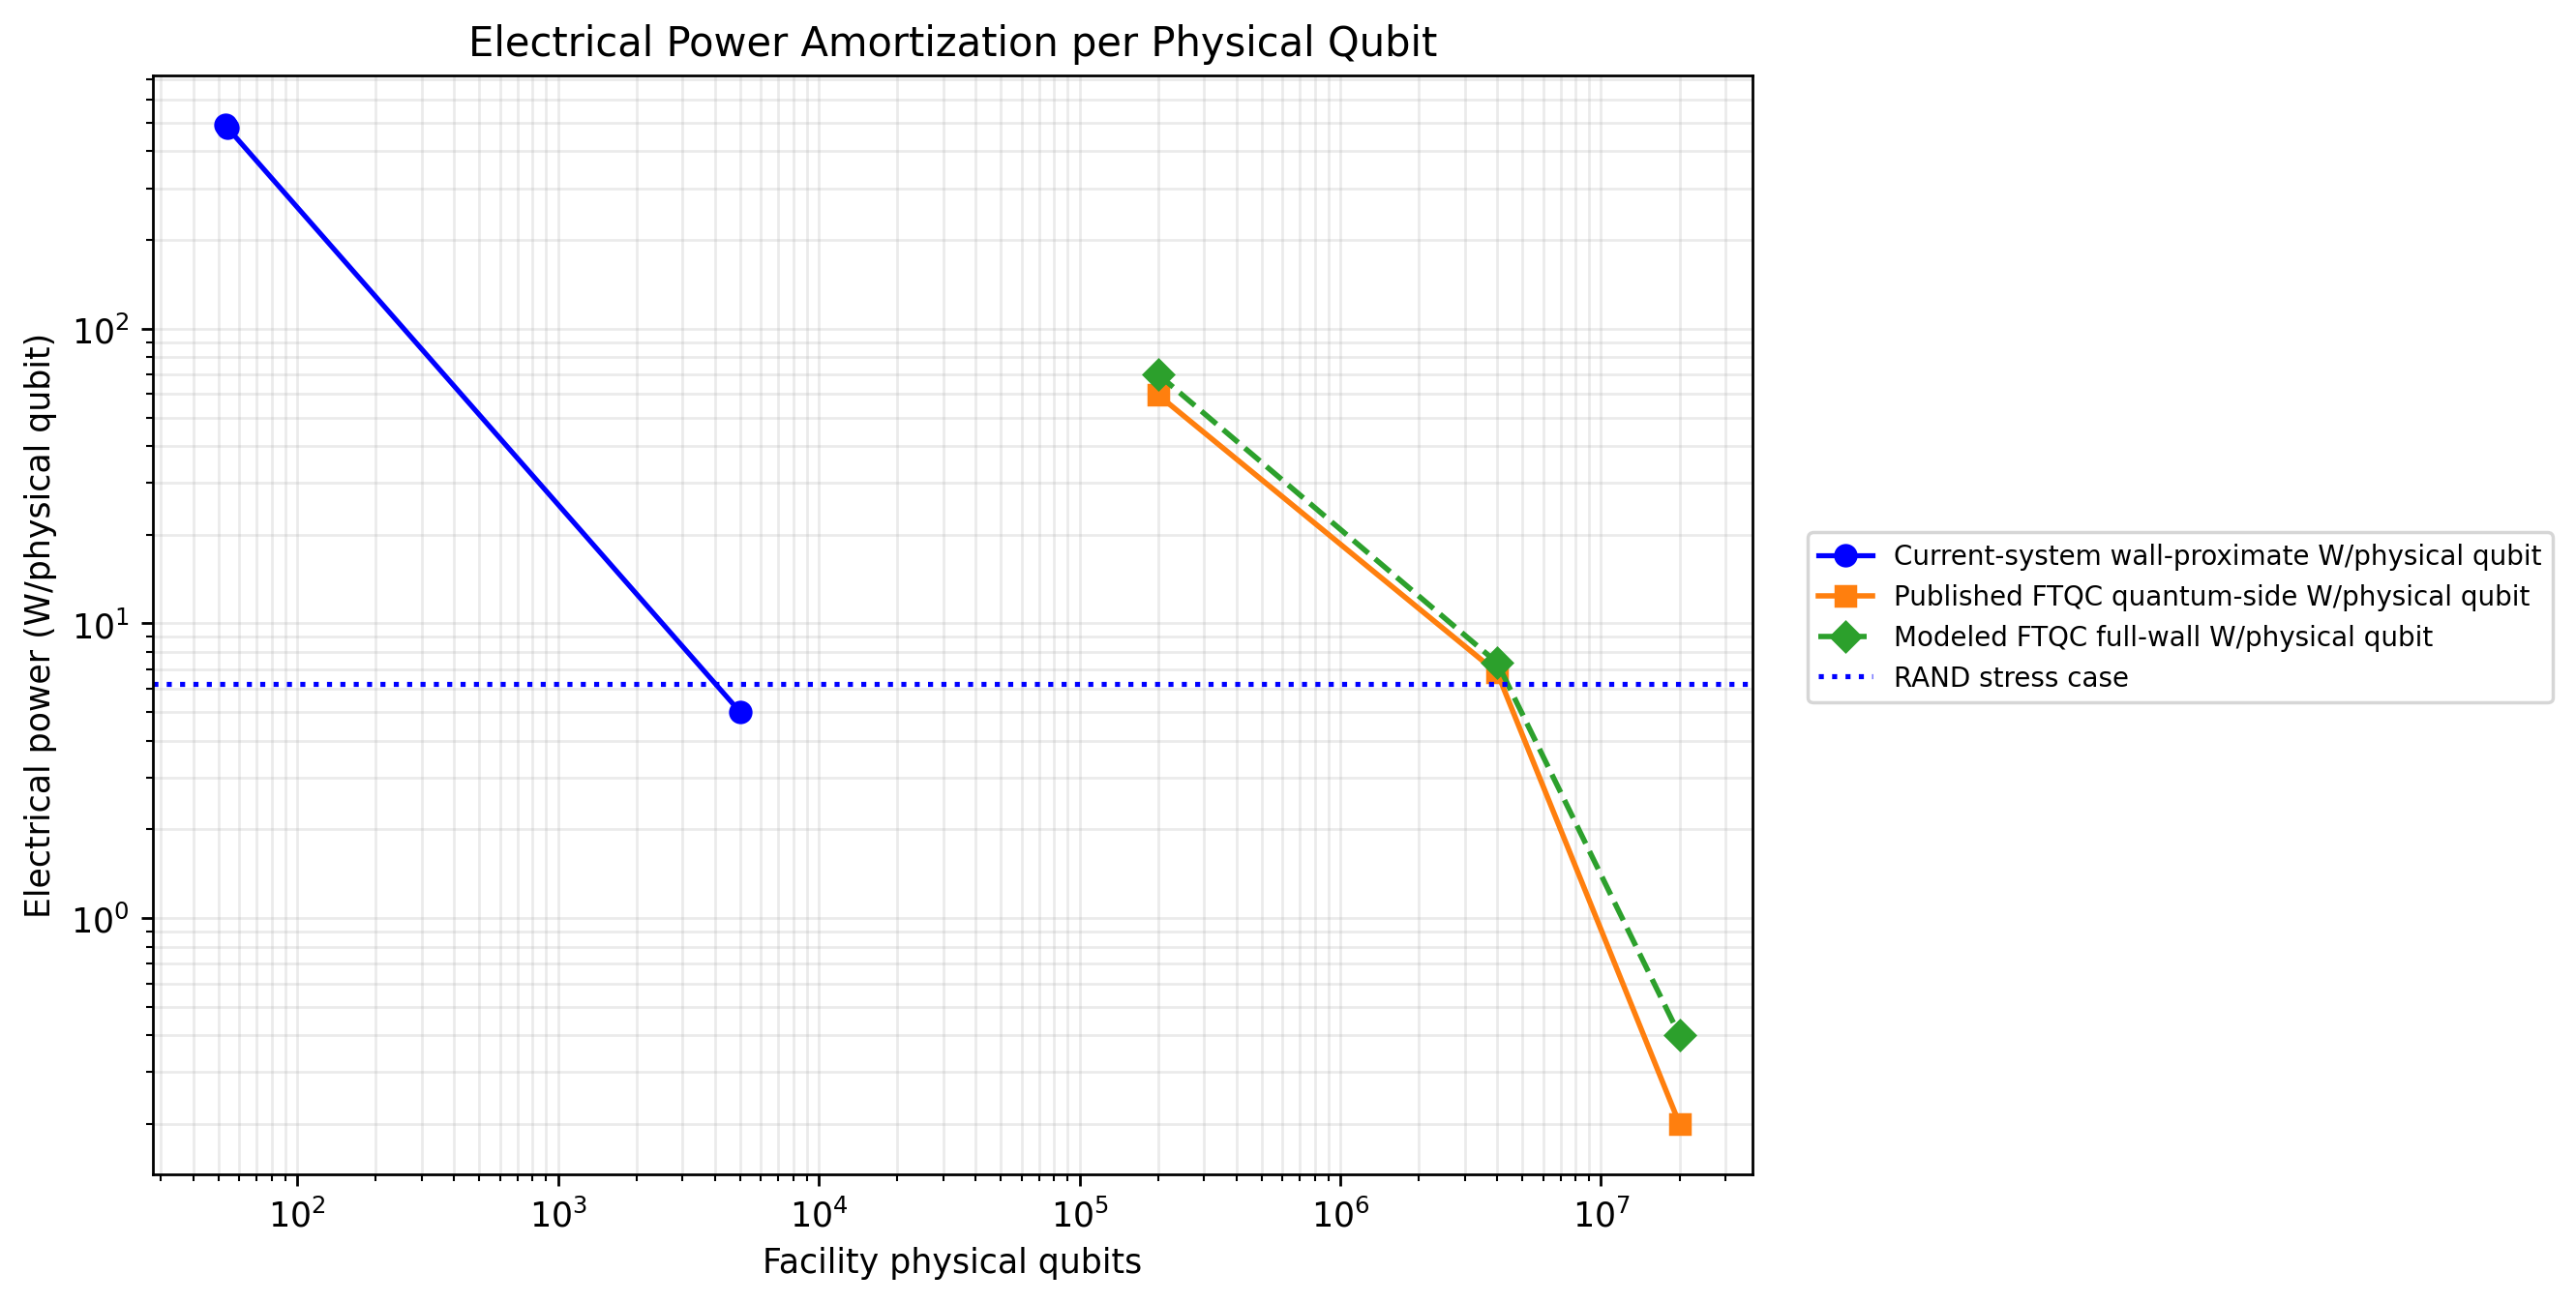

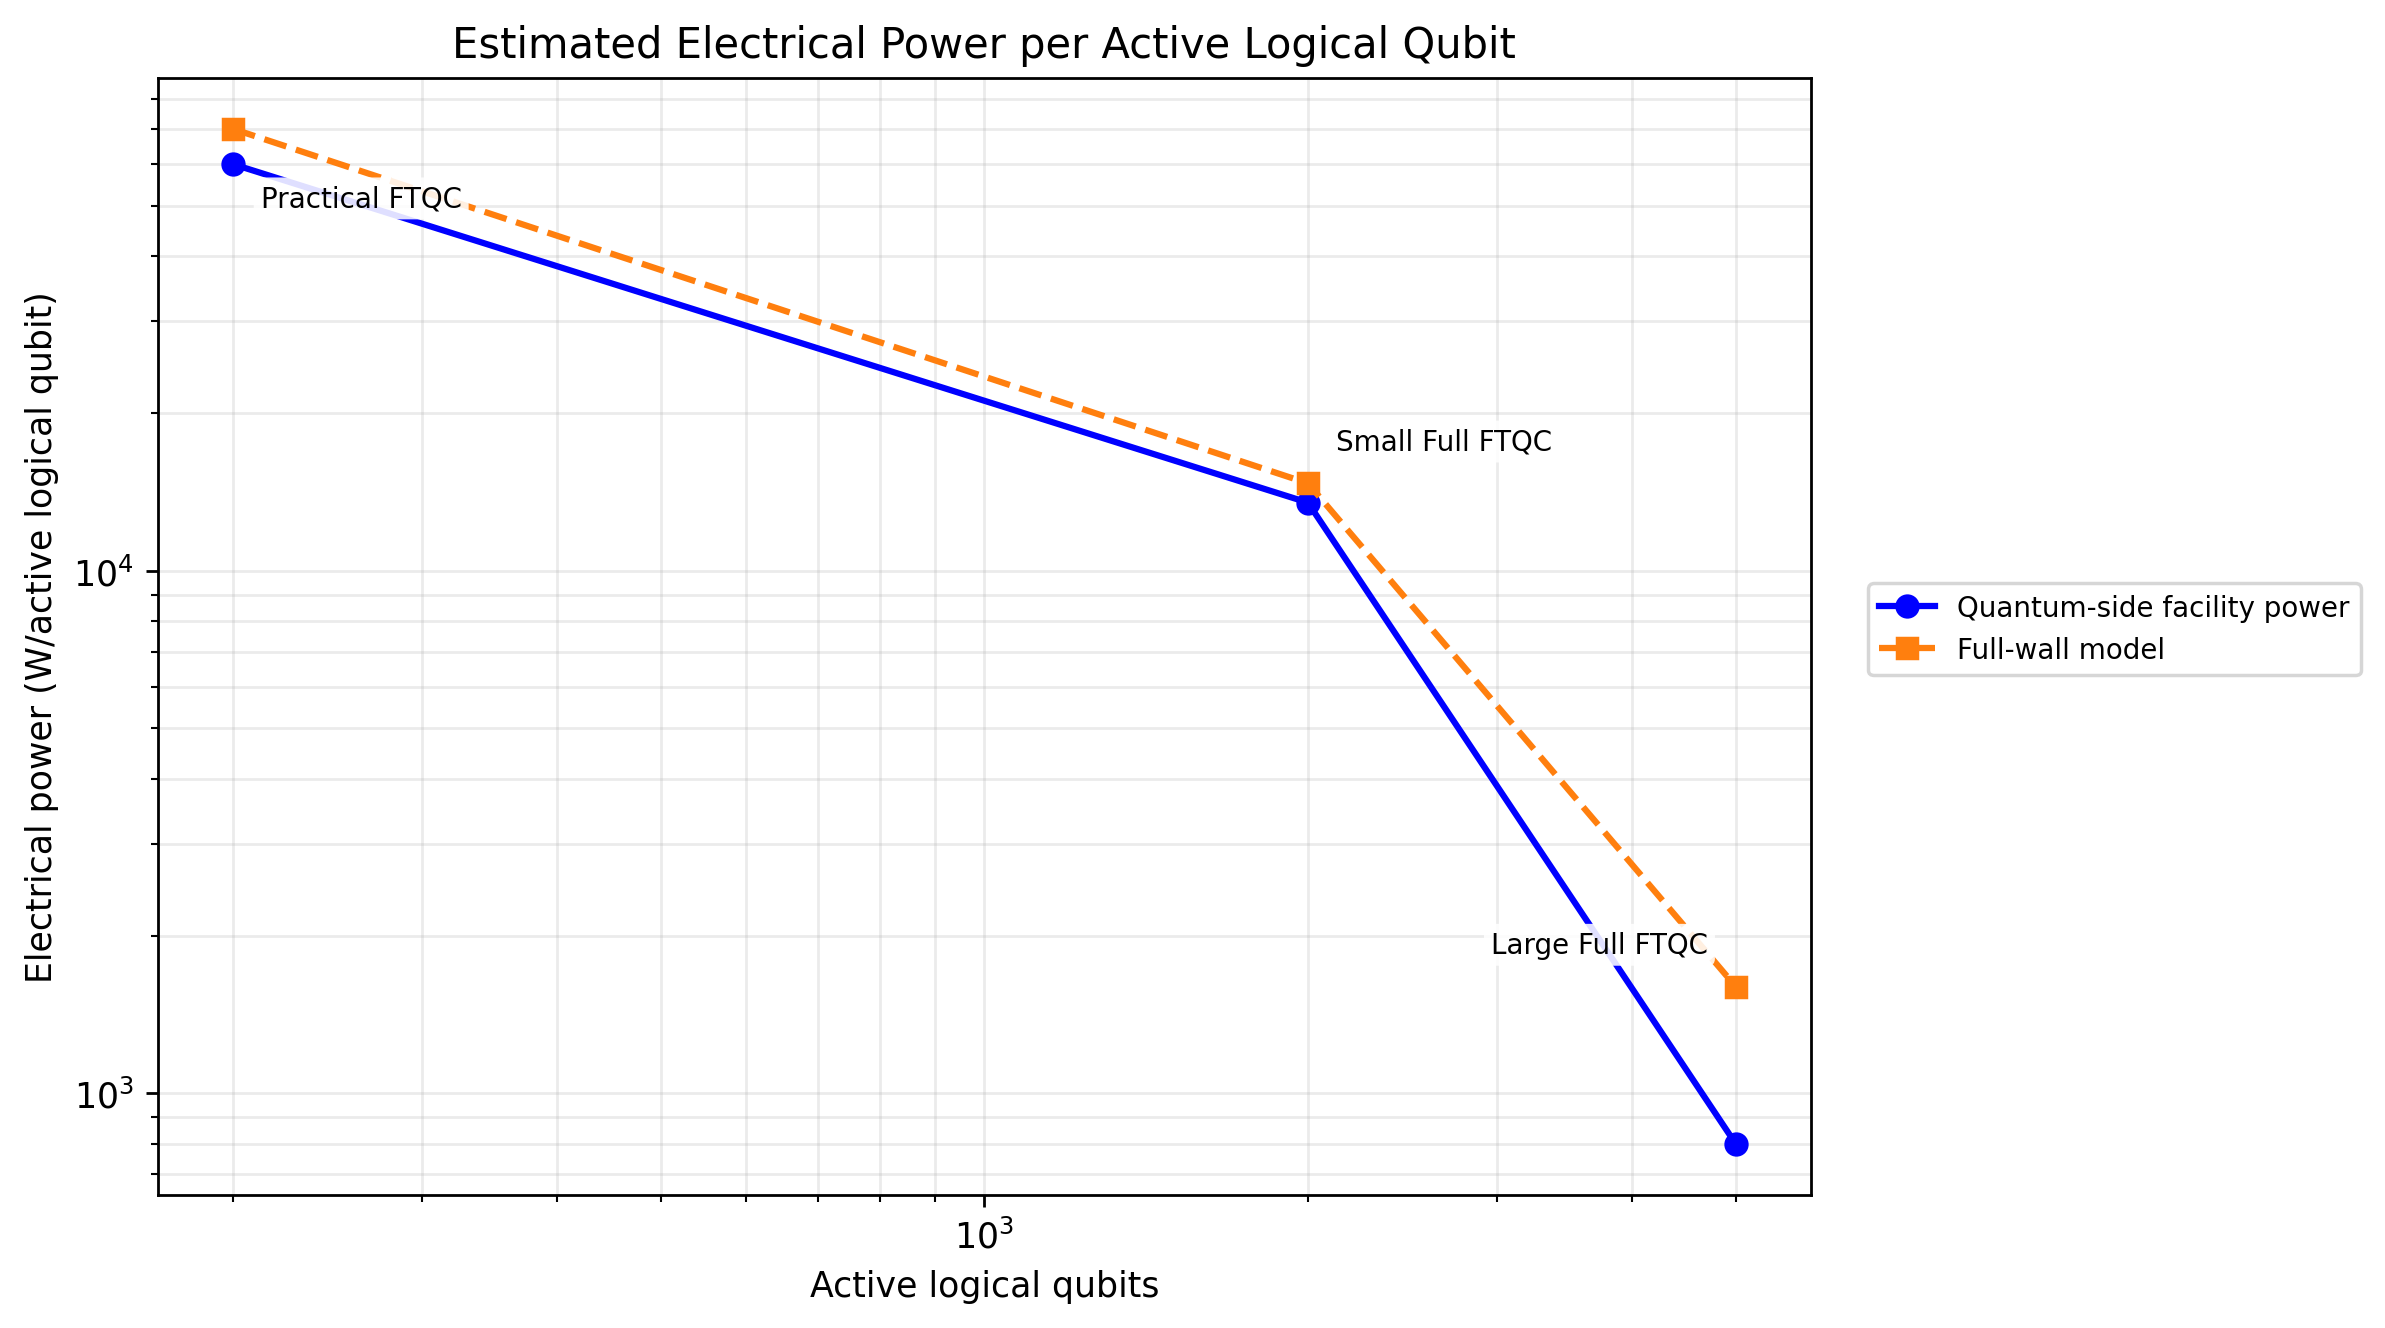

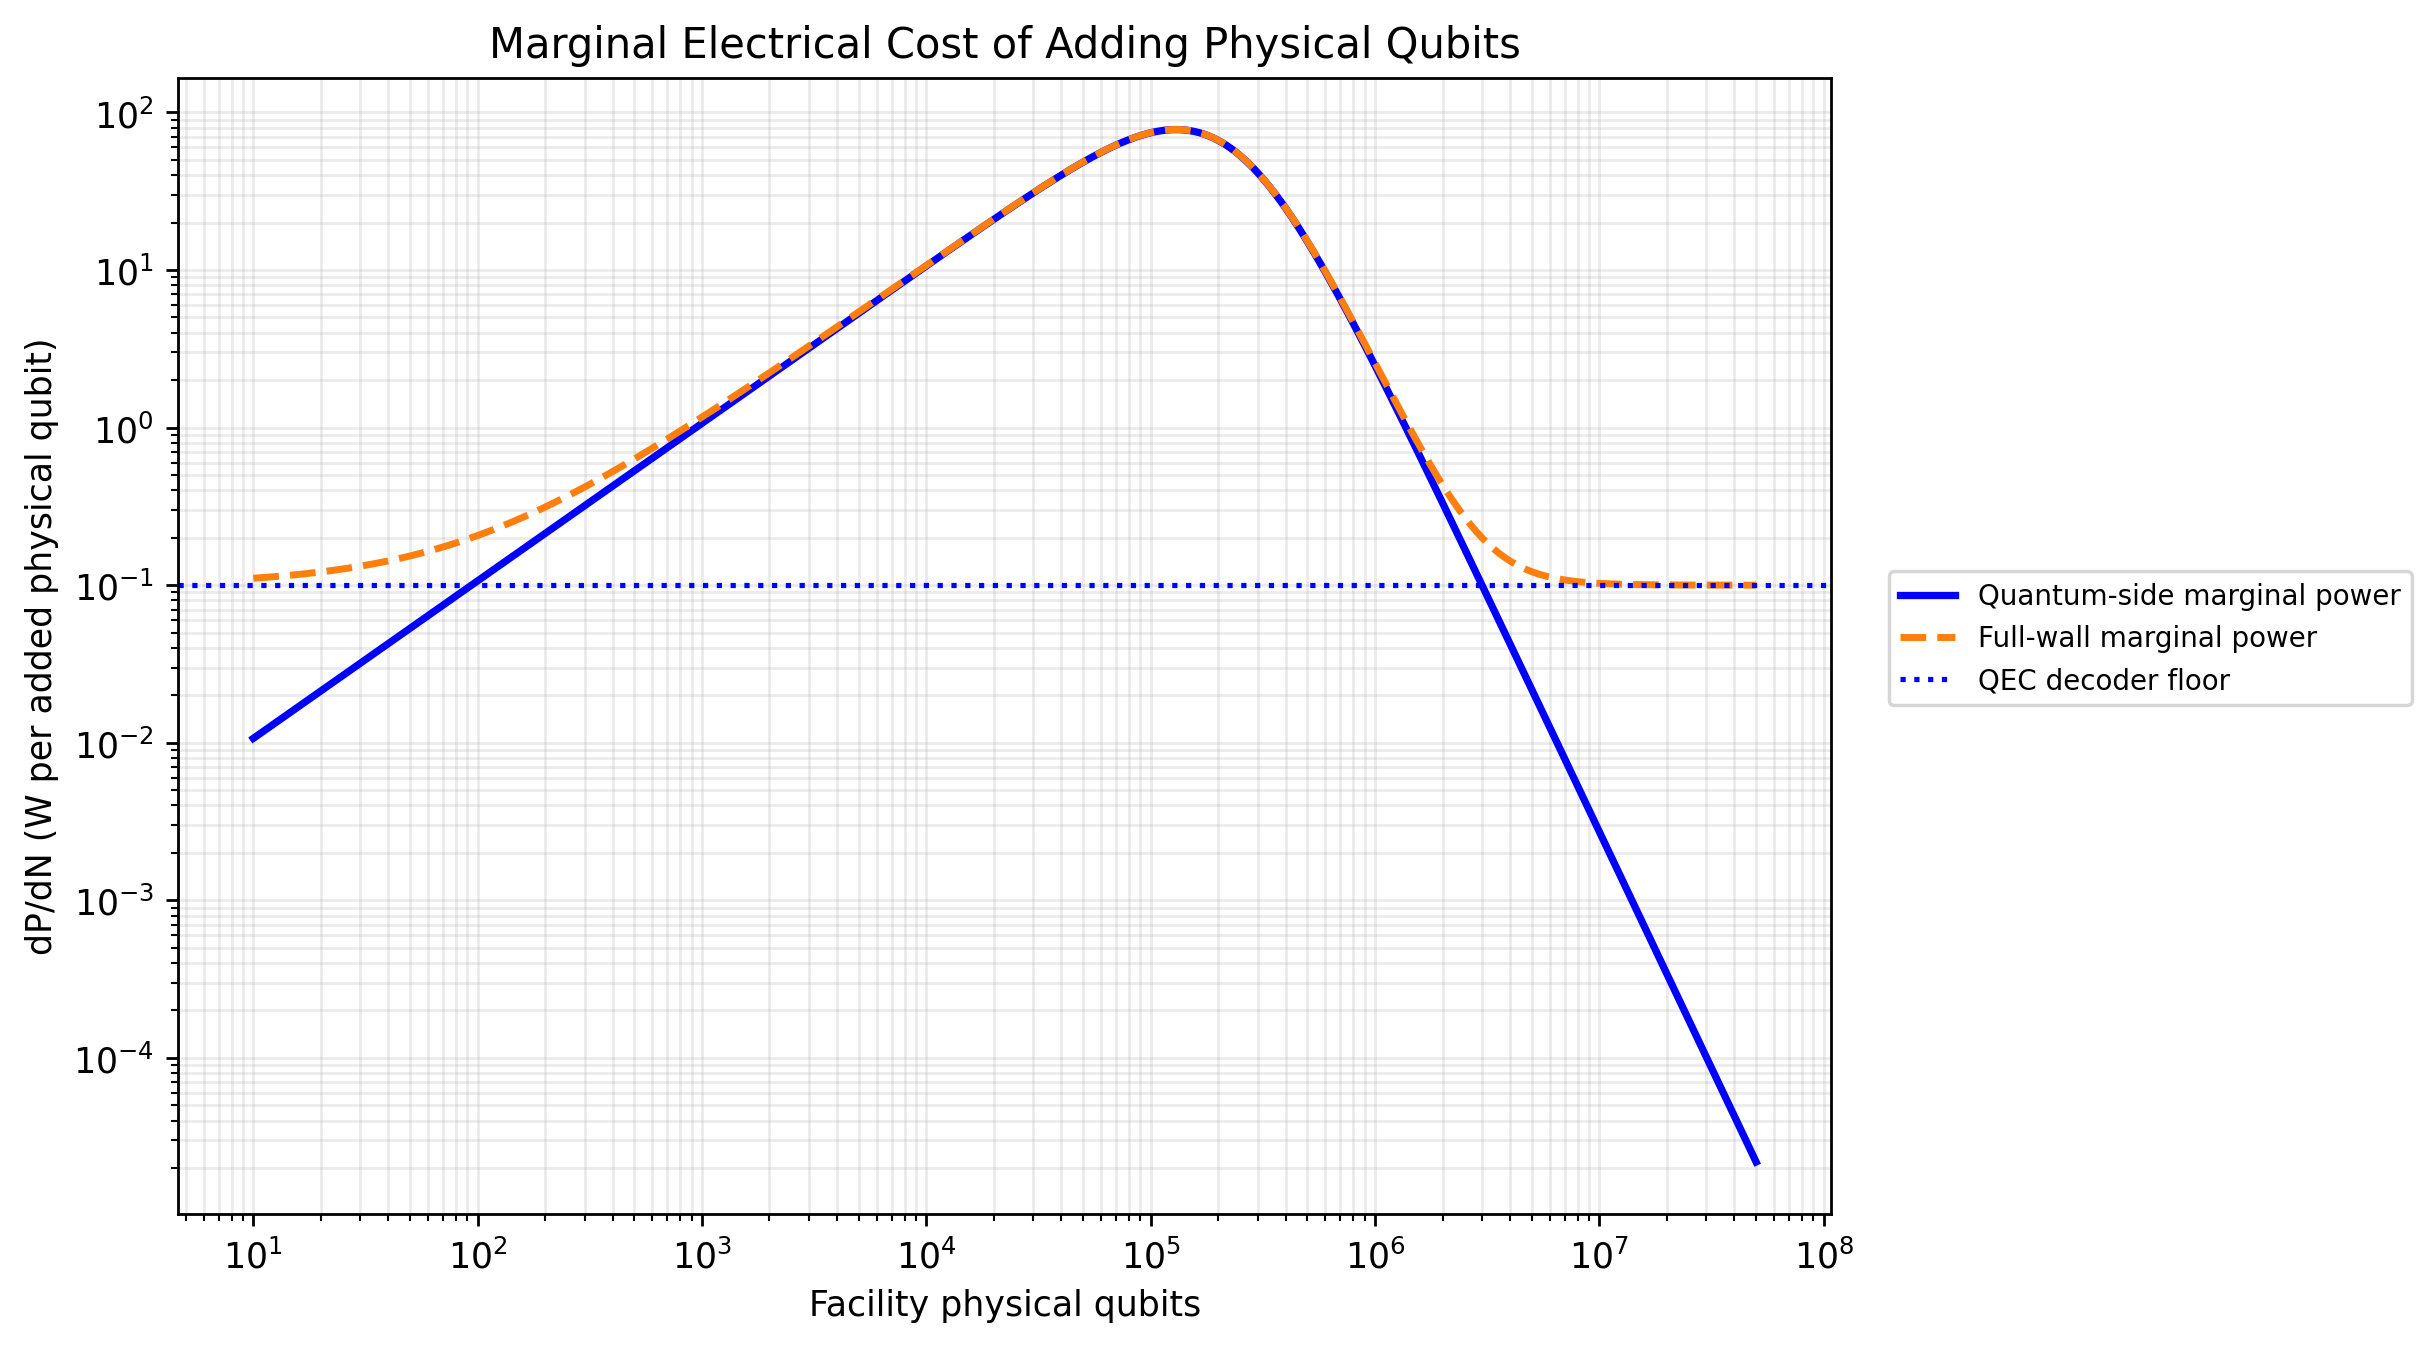

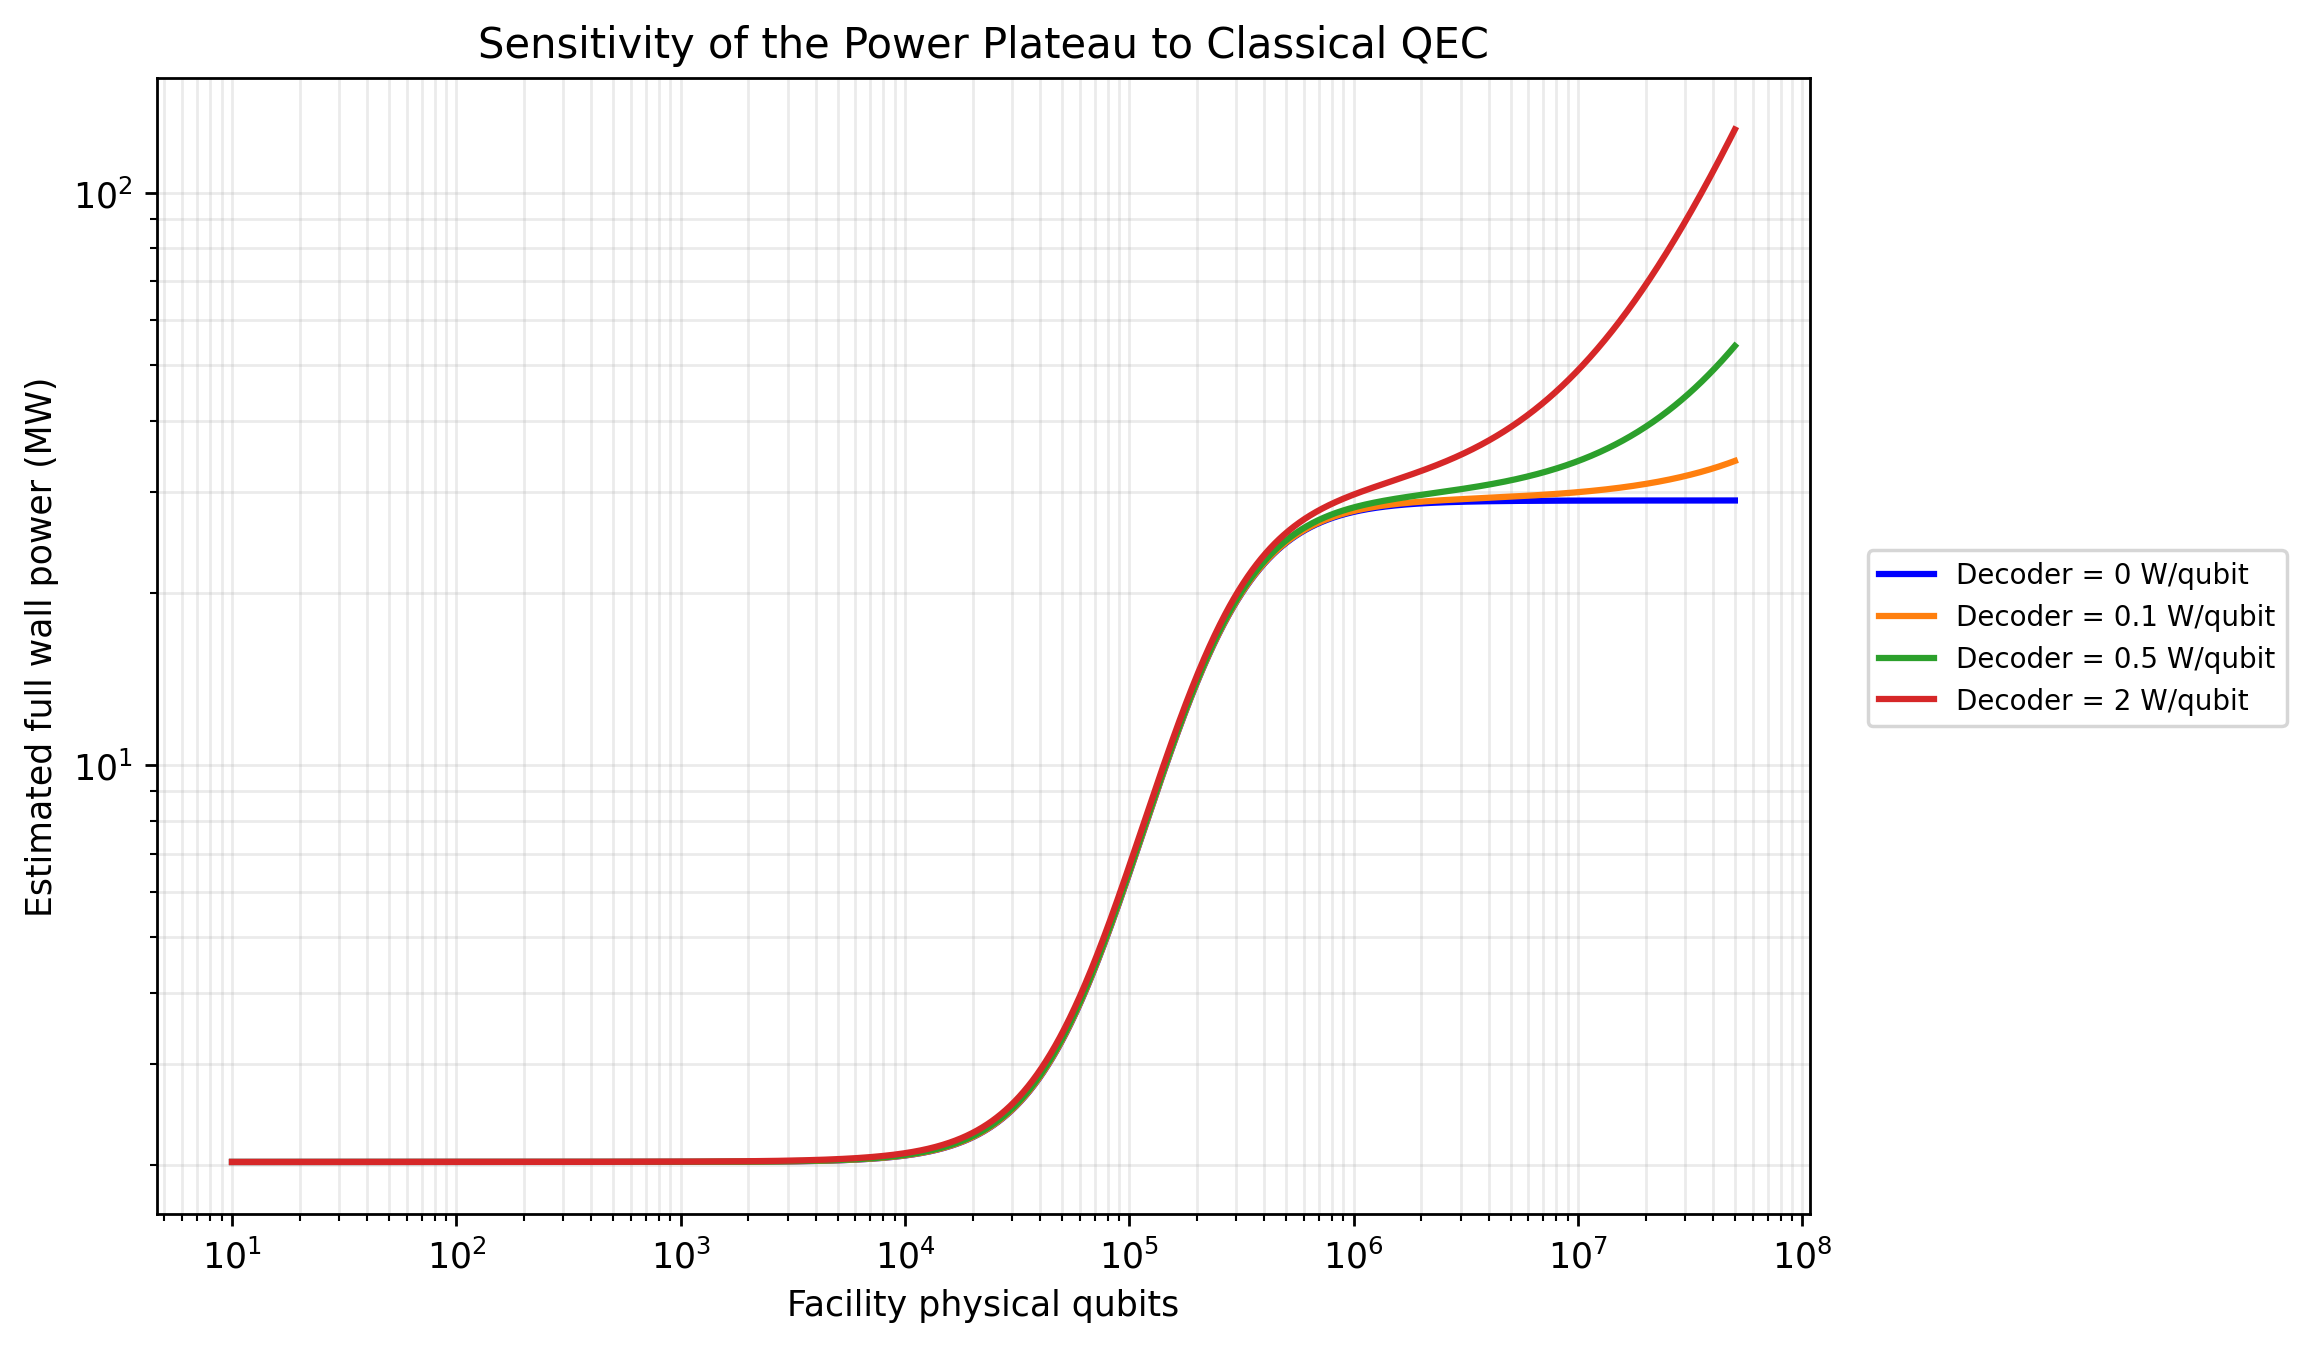

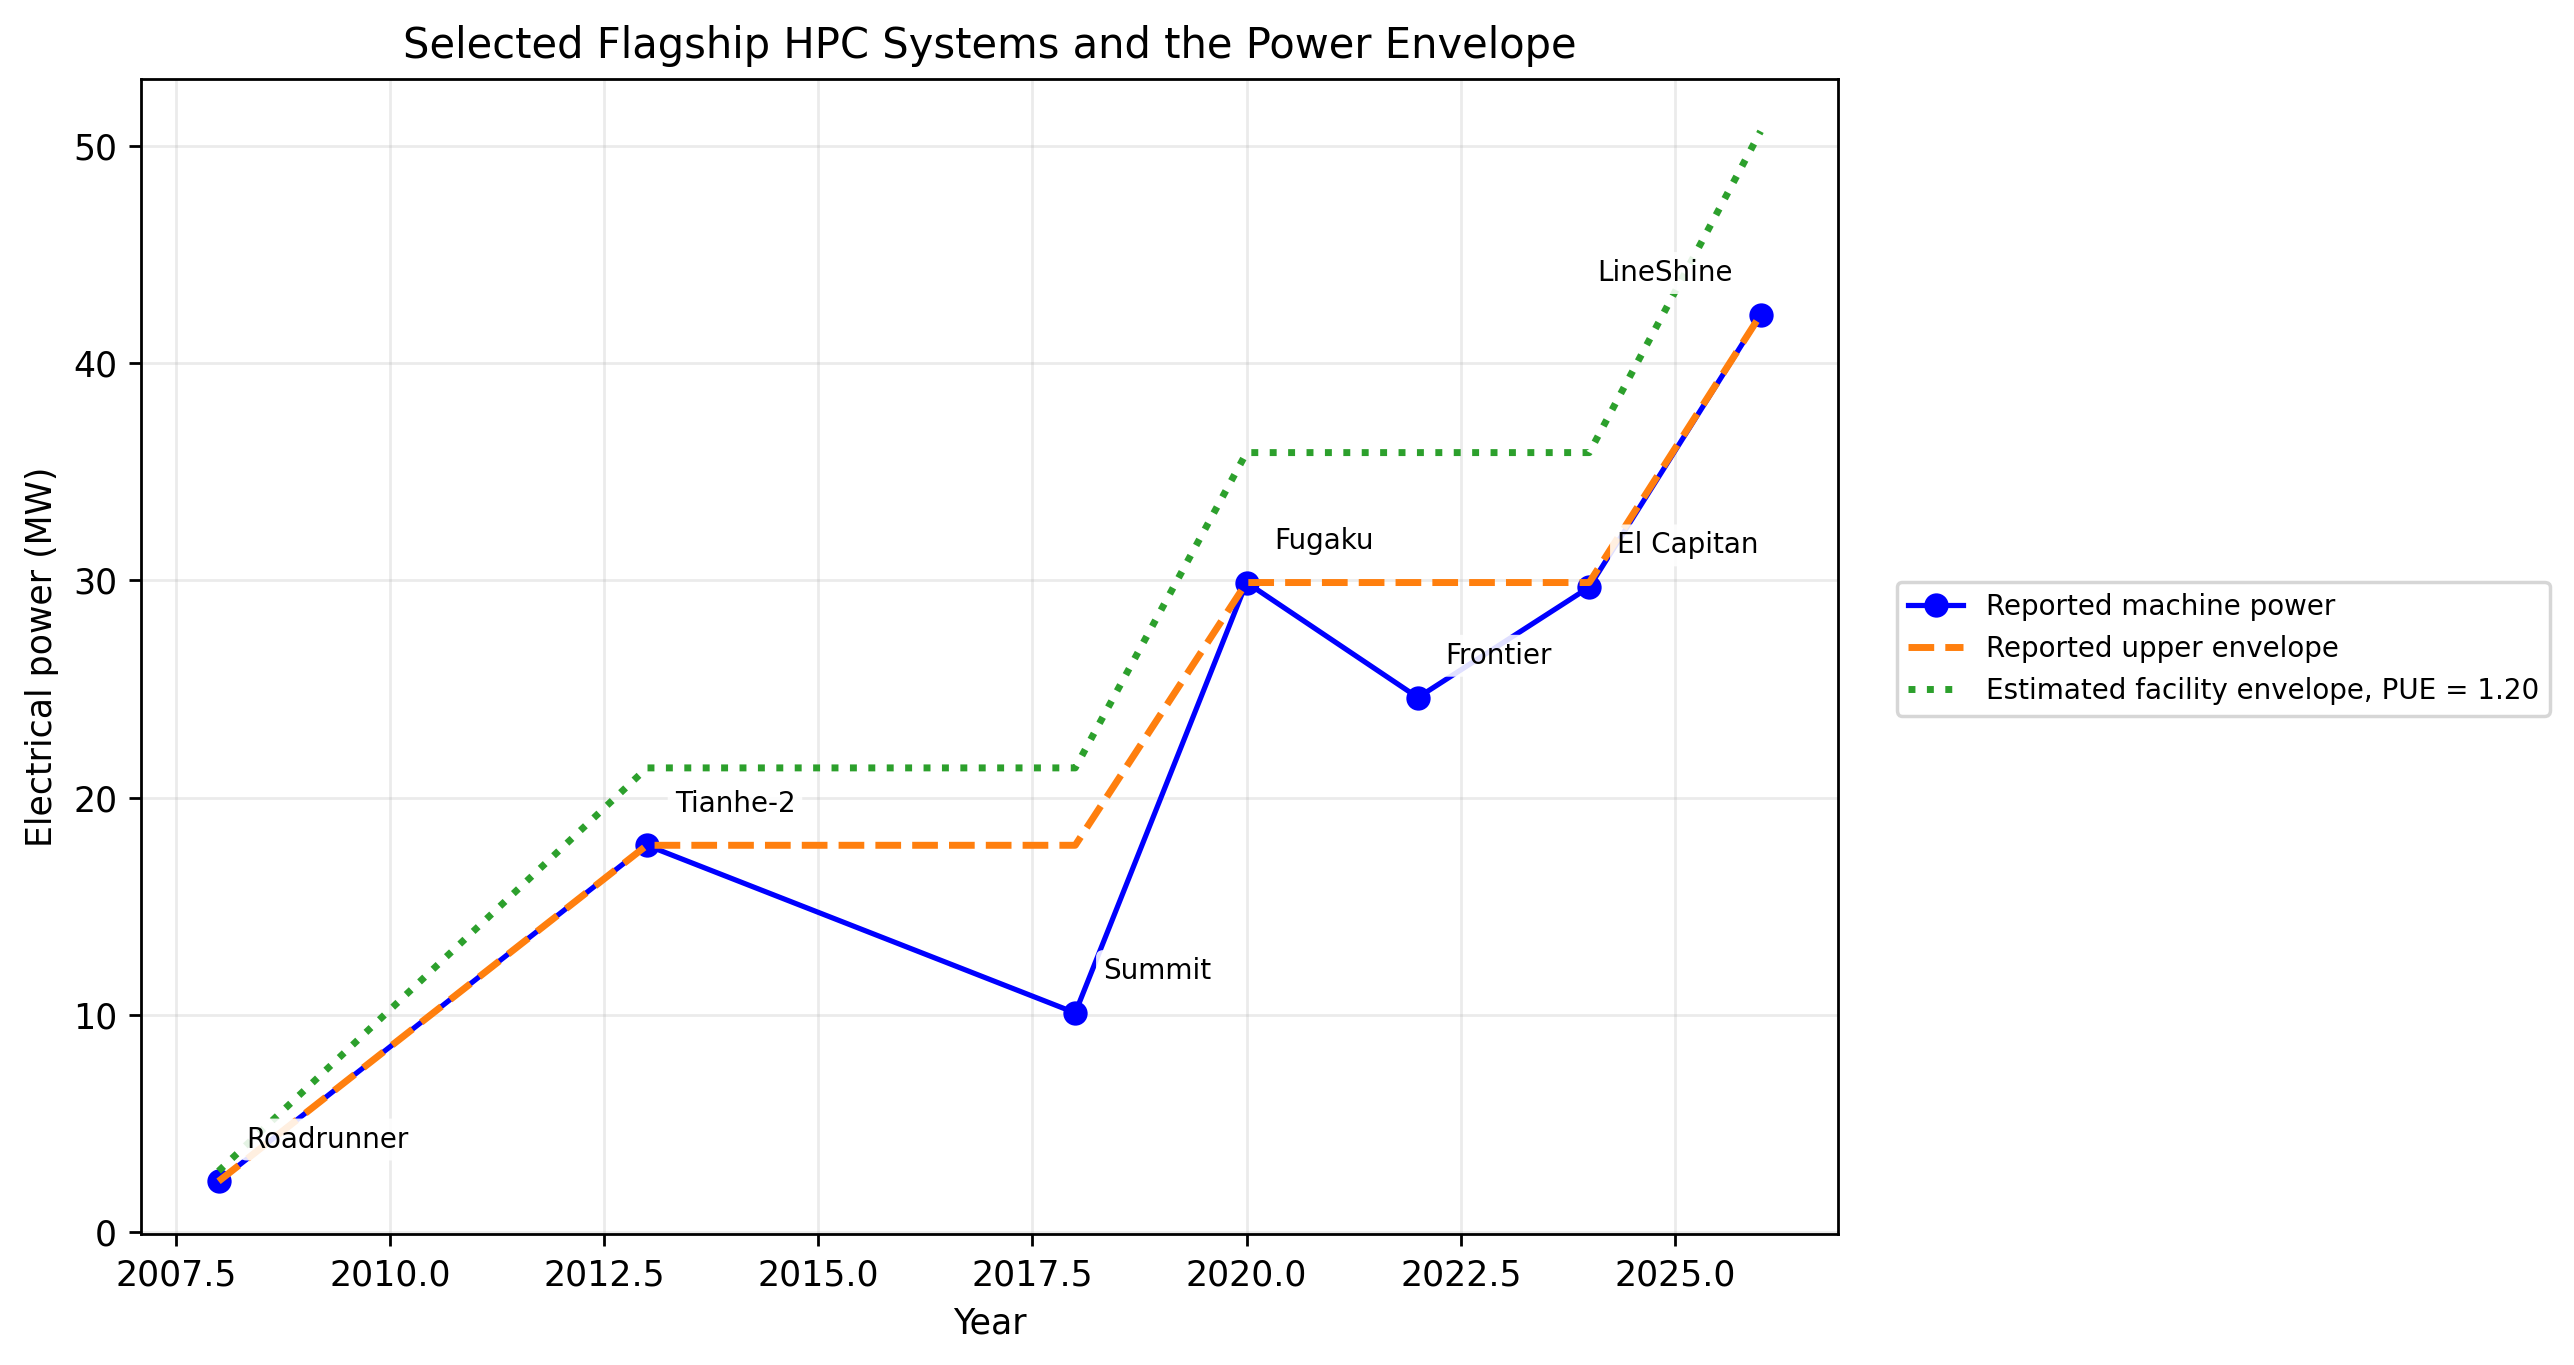

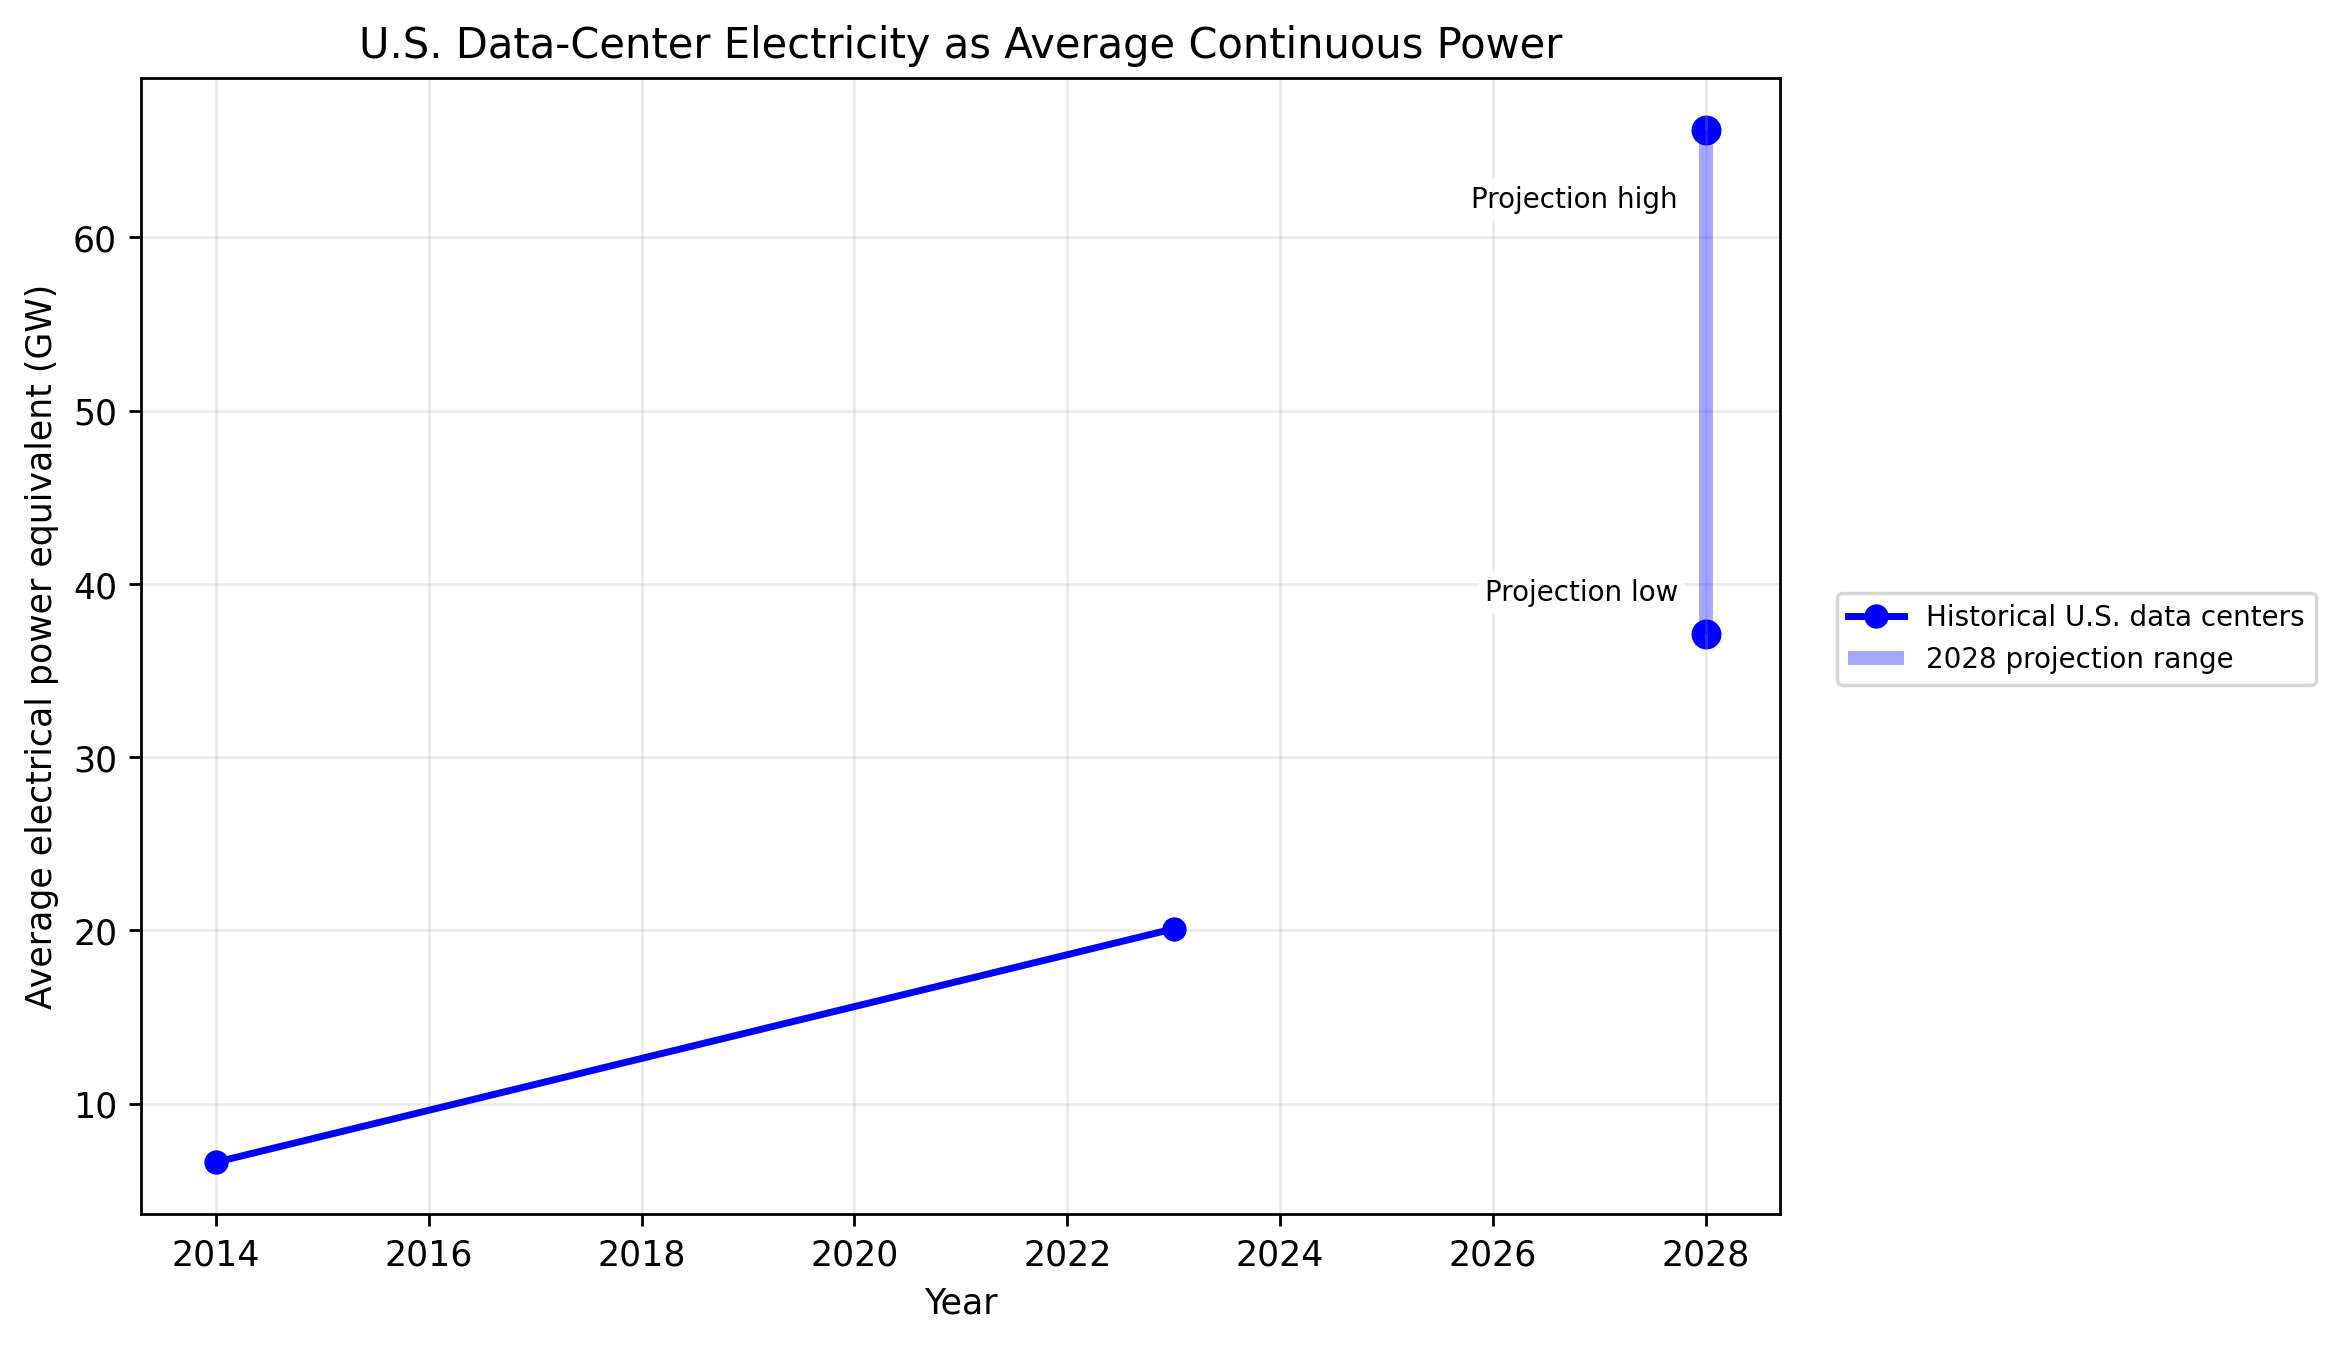

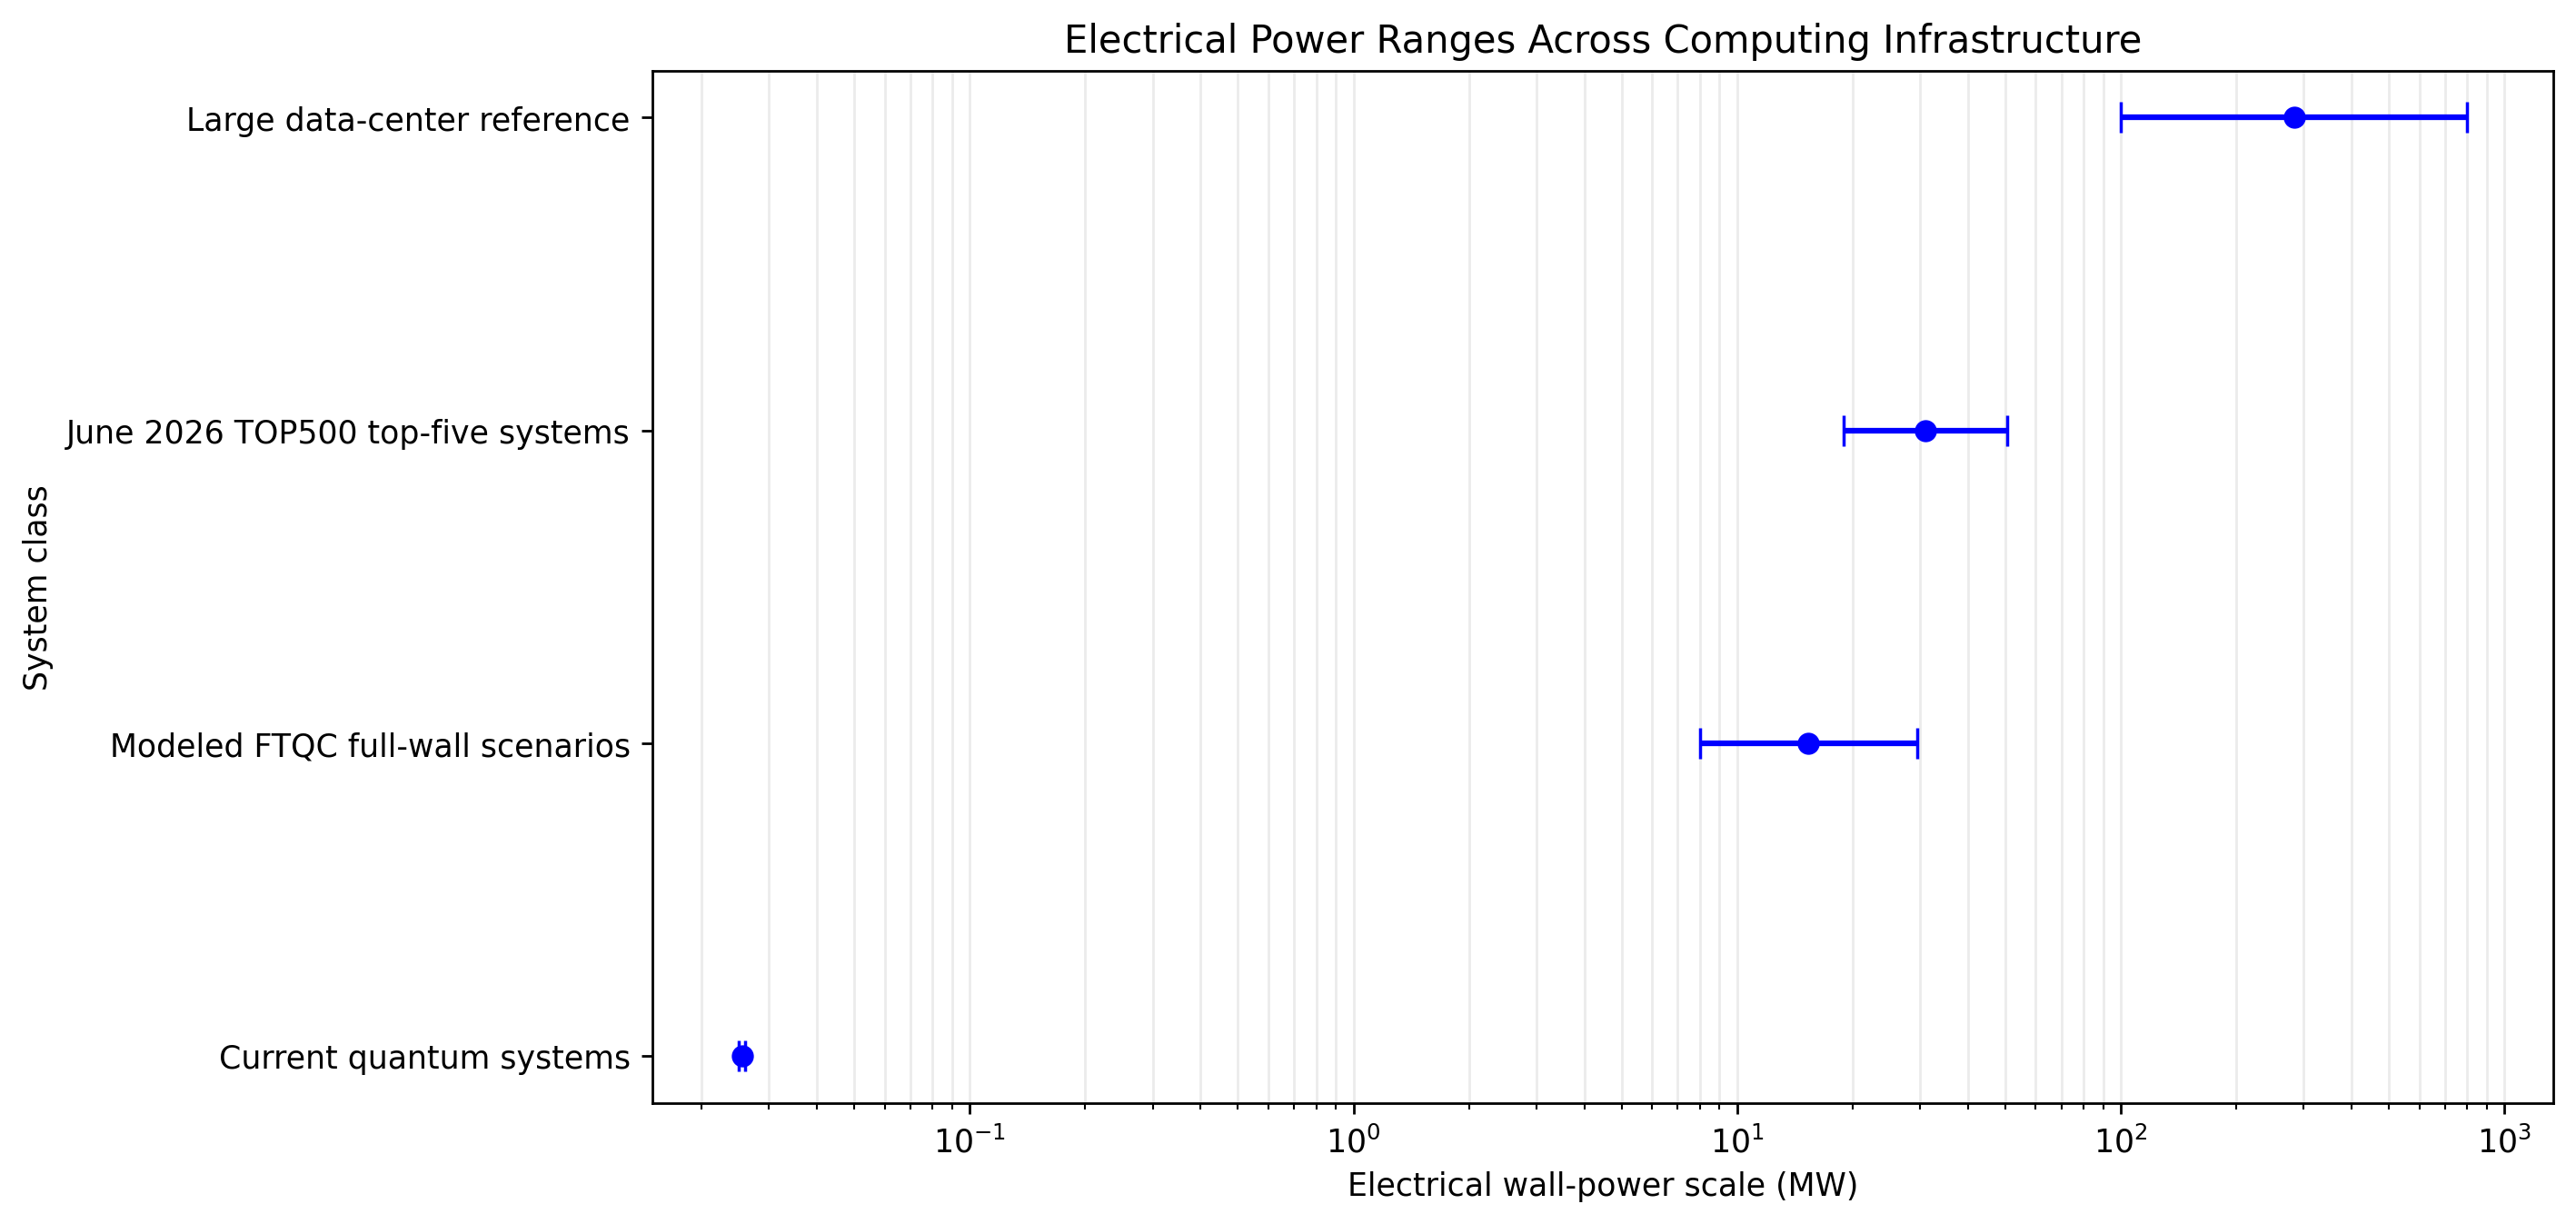


Diagnostics
Quantum-side saturation model at 20 million physical qubits: 27.00 MW
Full-wall model at 20 million physical qubits: 31.00 MW
RAND constant-W/qubit stress case at 20 million physical qubits: 125.00 MW
Selected HPC upper power-envelope growth, 2008 to 2026: 18.0x
U.S. data-center 2023 average-power equivalent: 20.1 GW
U.S. data-center 2028 projected average-power range: 37.1 to 66.2 GW


In [5]:
"""Model wall-power scaling across quantum, HPC, and data-center systems.

The notebook compares measured or vendor-specified quantum-system electrical
power, published fault-tolerant quantum-computing scenarios, TOP500
supercomputer power, and U.S. data-center electricity demand.

Future FTQC wall power is represented as the published quantum-side facility
estimate plus adjustable classical host and real-time QEC decoding loads.
A bounded Hill model provides an interpretable saturation hypothesis, and a
constant-watts-per-qubit model provides a linear stress case.
"""

import importlib.util
import os
import pdb
import subprocess
import sys
import tempfile
import traceback
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython import get_ipython
from IPython.display import display


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

FIGURE_DPI = 250

PURE_BLUE = "#0000FF"
MATPLOTLIB_COLOR_CYCLE = (
    PURE_BLUE,
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
)

QUBIT_MIN = 10
QUBIT_MAX = 50_000_000
QUBIT_POINTS = 2_000

CURRENT_QUANTUM_BASELOAD_MW = 0.026
PLATEAU_POWER_MW = 27.0
PLATEAU_KNEE_QUBITS = 225_000
PLATEAU_HILL_EXPONENT = 2.0

FTQC_CLASSICAL_HOST_MW = 2.0
FTQC_QEC_DECODER_W_PER_PHYSICAL_QUBIT = 0.10
DECODER_SENSITIVITY_W_PER_QUBIT = (0.0, 0.10, 0.50, 2.00)

RAND_W_PER_PHYSICAL_QUBIT = 6.25

HPC_FACILITY_PUE = 1.20
HOURS_PER_YEAR = 8_760.0

LABEL_FONT_SIZE = 8
LABEL_KEEP_OUT_PX = 8.0
LABEL_BOUNDARY_KEEP_OUT_PX = 12.0
LABEL_BOX_PAD = 0.25
LABEL_CANDIDATE_OFFSETS_PT = (
    (8, 8),
    (8, -16),
    (-8, 8),
    (-8, -16),
    (0, 16),
    (0, -20),
    (18, 0),
    (-18, 0),
    (22, 14),
    (-22, 14),
    (22, -18),
    (-22, -18),
    (30, 0),
    (-30, 0),
)

EXTERNAL_LEGEND_AXES_RIGHT = 0.70
EXTERNAL_LEGEND_X = 0.72
EXTERNAL_LEGEND_Y = 0.50

SANKEY_NODE_PAD_PX = 18
SANKEY_NODE_THICKNESS_PX = 18
SANKEY_HEIGHT_PX = 760
SANKEY_WIDTH_PX = 1_180

SHOW_DATA_TABLES = True
SHOW_QUANTUM_POWER_SCALING = True
SHOW_FTQC_POWER_BREAKDOWN = True
SHOW_CROSS_PLATFORM_WALL_POWER = True
SHOW_WATTS_PER_PHYSICAL_QUBIT = True
SHOW_WATTS_PER_ACTIVE_LOGICAL_QUBIT = True
SHOW_MARGINAL_POWER = True
SHOW_DECODER_SENSITIVITY = True
SHOW_HPC_POWER_ENVELOPE = True
SHOW_DATA_CENTER_AVERAGE_POWER = True
SHOW_SCALE_CONTEXT = True
SHOW_FTQC_POWER_SANKEY = True
SHOW_HPC_PUE_SANKEY = True

RUN_API_PREFLIGHT = True
RUN_PYLINT_SELF_CHECK = True
PYLINT_REQUIRED = True
ENABLE_PDB_POST_MORTEM = False

HEADLESS_VALIDATION = os.environ.get(
    "POWER_MODEL_HEADLESS",
    "0",
).strip() == "1"

plt.rcParams.update(
    {
        "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI,
        "axes.prop_cycle": plt.cycler(color=MATPLOTLIB_COLOR_CYCLE),
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
        "figure.autolayout": False,
    }
)


# -----------------------------------------------------------------------------
# Data structures
# -----------------------------------------------------------------------------

@dataclass(frozen=True)
class LabelSpec:
    """Describe one collision-managed data label."""

    text: str
    x: float
    y: float


@dataclass(frozen=True)
class PowerData:
    """Store all tabular datasets used by the visualizations."""

    quantum_current: pd.DataFrame
    ftqc: pd.DataFrame
    ftqc_component_intensity: pd.DataFrame
    hpc_current: pd.DataFrame
    hpc_history: pd.DataFrame
    data_center: pd.DataFrame


# -----------------------------------------------------------------------------
# Data preparation
# -----------------------------------------------------------------------------

def build_power_data() -> PowerData:
    """Build measured, vendor-specified, and scenario power tables."""
    quantum_current = pd.DataFrame(
        {
            "System": [
                "Google Sycamore",
                "IQM Radiance",
                "D-Wave Advantage",
            ],
            "Architecture": [
                "Gate-model superconducting",
                "Gate-model superconducting",
                "Quantum annealing",
            ],
            "Physical_qubits": [
                53,
                54,
                5_000,
            ],
            "Reported_power_MW": [
                0.026,
                0.026,
                0.025,
            ],
            "Power_basis": [
                "Apparatus average estimate",
                "Typical mean total electrical power",
                "Maximum rated electrical power",
            ],
            "Reference": [
                "Arute et al. (2019), Supplementary Information",
                "IQM Radiance product specification",
                "D-Wave Advantage datasheet v10",
            ],
        }
    )

    ftqc = pd.DataFrame(
        {
            "Scenario": [
                "Practical FTQC",
                "Small Full FTQC",
                "Large Full FTQC",
            ],
            "Active_logical_qubits": [
                200,
                2_000,
                5_000,
            ],
            "Physical_per_logical": [
                500,
                1_000,
                2_000,
            ],
            "Redundancy_factor": [
                2,
                2,
                2,
            ],
            "Quantum_side_power_MW": [
                12.0,
                27.0,
                4.0,
            ],
            "Published_W_per_physical_qubit": [
                59.7,
                6.8,
                0.2,
            ],
        }
    )

    ftqc["Facility_physical_qubits"] = (
        ftqc["Active_logical_qubits"]
        * ftqc["Physical_per_logical"]
        * ftqc["Redundancy_factor"]
    )

    ftqc["QEC_decoder_power_MW"] = (
        ftqc["Facility_physical_qubits"]
        * FTQC_QEC_DECODER_W_PER_PHYSICAL_QUBIT
        / 1_000_000.0
    )

    ftqc["Classical_host_power_MW"] = FTQC_CLASSICAL_HOST_MW

    ftqc["Estimated_full_wall_power_MW"] = (
        ftqc["Quantum_side_power_MW"]
        + ftqc["QEC_decoder_power_MW"]
        + ftqc["Classical_host_power_MW"]
    )

    ftqc["Full_wall_W_per_physical_qubit"] = (
        ftqc["Estimated_full_wall_power_MW"]
        * 1_000_000.0
        / ftqc["Facility_physical_qubits"]
    )

    ftqc["Quantum_side_W_per_active_logical_qubit"] = (
        ftqc["Quantum_side_power_MW"]
        * 1_000_000.0
        / ftqc["Active_logical_qubits"]
    )

    ftqc["Full_wall_W_per_active_logical_qubit"] = (
        ftqc["Estimated_full_wall_power_MW"]
        * 1_000_000.0
        / ftqc["Active_logical_qubits"]
    )

    ftqc_component_intensity = pd.DataFrame(
        {
            "Scenario": [
                "Practical FTQC",
                "Small Full FTQC",
                "Large Full FTQC",
            ],
            "Baseload IT": [
                5.0,
                0.6,
                0.02,
            ],
            "Miscellaneous": [
                5.0,
                0.6,
                0.02,
            ],
            "Cooling water": [
                12.3,
                1.4,
                0.1,
            ],
            "Cryogenics": [
                32.4,
                4.2,
                0.1,
            ],
            "Control electronics": [
                5.0,
                0.005,
                0.005,
            ],
        }
    )

    hpc_current = pd.DataFrame(
        {
            "System": [
                "LineShine",
                "El Capitan",
                "Frontier",
                "Aurora",
                "JUPITER Booster",
            ],
            "TOP500_rank_June_2026": [
                1,
                2,
                3,
                4,
                5,
            ],
            "Reported_machine_power_MW": [
                42.220,
                29.685,
                24.607,
                38.698,
                15.79381,
            ],
        }
    )

    hpc_current["Estimated_facility_wall_MW"] = (
        hpc_current["Reported_machine_power_MW"]
        * HPC_FACILITY_PUE
    )

    hpc_current["Estimated_PUE_overhead_MW"] = (
        hpc_current["Estimated_facility_wall_MW"]
        - hpc_current["Reported_machine_power_MW"]
    )

    hpc_history = pd.DataFrame(
        {
            "Year": [
                2008,
                2013,
                2018,
                2020,
                2022,
                2024,
                2026,
            ],
            "System": [
                "Roadrunner",
                "Tianhe-2",
                "Summit",
                "Fugaku",
                "Frontier",
                "El Capitan",
                "LineShine",
            ],
            "Reported_machine_power_MW": [
                2.345,
                17.808,
                10.096,
                29.89923,
                24.607,
                29.685,
                42.220,
            ],
        }
    )

    hpc_history["Estimated_facility_wall_MW"] = (
        hpc_history["Reported_machine_power_MW"]
        * HPC_FACILITY_PUE
    )

    hpc_history["Reported_power_envelope_MW"] = (
        hpc_history["Reported_machine_power_MW"].cummax()
    )

    hpc_history["Estimated_wall_envelope_MW"] = (
        hpc_history["Estimated_facility_wall_MW"].cummax()
    )

    data_center = pd.DataFrame(
        {
            "Year": [
                2014,
                2023,
                2028,
                2028,
            ],
            "Scenario": [
                "Historical",
                "Historical",
                "Projection low",
                "Projection high",
            ],
            "US_data_center_TWh_per_year": [
                58.0,
                176.0,
                325.0,
                580.0,
            ],
        }
    )

    data_center["Average_power_GW"] = (
        data_center["US_data_center_TWh_per_year"]
        * 1_000.0
        / HOURS_PER_YEAR
    )

    return PowerData(
        quantum_current=quantum_current,
        ftqc=ftqc,
        ftqc_component_intensity=ftqc_component_intensity,
        hpc_current=hpc_current,
        hpc_history=hpc_history,
        data_center=data_center,
    )


# -----------------------------------------------------------------------------
# Power models
# -----------------------------------------------------------------------------

def hill_plateau_power_mw(
    qubits: np.ndarray,
    base_power_mw: float,
    plateau_power_mw: float,
    knee_qubits: float,
    exponent: float,
) -> np.ndarray:
    """Return a bounded Hill-type power-saturation curve."""
    ratio = (qubits / knee_qubits) ** exponent

    return (
        base_power_mw
        + (plateau_power_mw - base_power_mw)
        * ratio
        / (1.0 + ratio)
    )


def hill_plateau_marginal_w_per_qubit(
    qubits: np.ndarray,
    base_power_mw: float,
    plateau_power_mw: float,
    knee_qubits: float,
    exponent: float,
) -> np.ndarray:
    """Return the derivative of the Hill power curve in W per added qubit."""
    ratio = (qubits / knee_qubits) ** exponent
    delta_power_mw = plateau_power_mw - base_power_mw

    derivative_mw_per_qubit = (
        delta_power_mw
        * exponent
        * ratio
        / qubits
        / (1.0 + ratio) ** 2
    )

    return derivative_mw_per_qubit * 1_000_000.0


def linear_power_mw(
    qubits: np.ndarray,
    watts_per_qubit: float,
) -> np.ndarray:
    """Return electrical power for a constant W-per-qubit model."""
    return qubits * watts_per_qubit / 1_000_000.0


def full_wall_power_mw(
    quantum_side_power_mw: np.ndarray,
    qubits: np.ndarray,
    classical_host_mw: float,
    decoder_w_per_qubit: float,
) -> np.ndarray:
    """Return quantum-side power plus classical host and decoder power."""
    return (
        quantum_side_power_mw
        + classical_host_mw
        + linear_power_mw(
            qubits,
            decoder_w_per_qubit,
        )
    )


def normalize_component_breakdown(
    scenario_row: pd.Series,
    target_total_mw: float,
) -> pd.Series:
    """Scale rounded component intensities to a published scenario total."""
    values = scenario_row.drop(labels=["Scenario"]).astype(float)
    return values / values.sum() * target_total_mw


def build_component_table(data: PowerData) -> pd.DataFrame:
    """Return normalized FTQC subsystem power in MW for each scenario."""
    normalized_components = []

    for _, ftqc_row in data.ftqc.iterrows():
        source_row = data.ftqc_component_intensity.loc[
            data.ftqc_component_intensity["Scenario"]
            == ftqc_row["Scenario"]
        ].iloc[0]

        normalized_components.append(
            normalize_component_breakdown(
                scenario_row=source_row,
                target_total_mw=float(ftqc_row["Quantum_side_power_MW"]),
            )
        )

    return pd.DataFrame(
        normalized_components,
        index=data.ftqc["Scenario"],
    )


# -----------------------------------------------------------------------------
# Plot layout helpers
# -----------------------------------------------------------------------------

def _expand_bbox(bbox: Bbox, padding_px: float) -> Bbox:
    """Return a display-coordinate bounding box expanded by padding."""
    return Bbox.from_extents(
        bbox.x0 - padding_px,
        bbox.y0 - padding_px,
        bbox.x1 + padding_px,
        bbox.y1 + padding_px,
    )


def _shrink_bbox(bbox: Bbox, padding_px: float) -> Bbox:
    """Return a display-coordinate bounding box reduced by padding."""
    return Bbox.from_extents(
        bbox.x0 + padding_px,
        bbox.y0 + padding_px,
        bbox.x1 - padding_px,
        bbox.y1 - padding_px,
    )


def _overlap_area(first: Bbox, second: Bbox) -> float:
    """Return overlap area between two display-coordinate bounding boxes."""
    width = max(
        0.0,
        min(first.x1, second.x1) - max(first.x0, second.x0),
    )
    height = max(
        0.0,
        min(first.y1, second.y1) - max(first.y0, second.y0),
    )
    return width * height


def _boundary_penalty(label_bbox: Bbox, safe_bbox: Bbox) -> float:
    """Return a scalar penalty for crossing the axes keepout boundary."""
    return (
        max(0.0, safe_bbox.x0 - label_bbox.x0)
        + max(0.0, label_bbox.x1 - safe_bbox.x1)
        + max(0.0, safe_bbox.y0 - label_bbox.y0)
        + max(0.0, label_bbox.y1 - safe_bbox.y1)
    )


def _alignment_for_offset(dx: float, dy: float) -> tuple[str, str]:
    """Return horizontal and vertical text alignment for an offset."""
    if dx > 0:
        horizontal = "left"
    elif dx < 0:
        horizontal = "right"
    else:
        horizontal = "center"

    if dy > 0:
        vertical = "bottom"
    elif dy < 0:
        vertical = "top"
    else:
        vertical = "center"

    return horizontal, vertical


def place_labels_with_keepout(
    ax: plt.Axes,
    labels: Sequence[LabelSpec],
) -> None:
    """Place point labels using collision and axes-boundary keepouts."""
    if not labels:
        return

    figure = ax.figure
    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    axes_bbox = ax.get_window_extent(renderer=renderer)
    safe_bbox = _shrink_bbox(
        axes_bbox,
        LABEL_BOUNDARY_KEEP_OUT_PX,
    )
    occupied_boxes: list[Bbox] = []

    for label in labels:
        best_offset = LABEL_CANDIDATE_OFFSETS_PT[0]
        best_penalty = float("inf")

        for dx, dy in LABEL_CANDIDATE_OFFSETS_PT:
            horizontal, vertical = _alignment_for_offset(dx, dy)
            annotation = ax.annotate(
                label.text,
                xy=(label.x, label.y),
                xytext=(dx, dy),
                textcoords="offset points",
                ha=horizontal,
                va=vertical,
                fontsize=LABEL_FONT_SIZE,
                bbox={
                    "boxstyle": f"round,pad={LABEL_BOX_PAD}",
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.88,
                },
                zorder=20,
            )

            figure.canvas.draw()
            label_bbox = annotation.get_window_extent(renderer=renderer)
            padded_bbox = _expand_bbox(
                label_bbox,
                LABEL_KEEP_OUT_PX,
            )

            overlap_penalty = sum(
                _overlap_area(padded_bbox, occupied)
                for occupied in occupied_boxes
            )
            edge_penalty = _boundary_penalty(
                padded_bbox,
                safe_bbox,
            )
            distance_penalty = 0.03 * (abs(dx) + abs(dy))
            total_penalty = (
                100.0 * overlap_penalty
                + 10_000.0 * edge_penalty
                + distance_penalty
            )

            annotation.remove()

            if total_penalty < best_penalty:
                best_penalty = total_penalty
                best_offset = (dx, dy)

            if overlap_penalty == 0.0 and edge_penalty == 0.0:
                break

        horizontal, vertical = _alignment_for_offset(*best_offset)
        final_annotation = ax.annotate(
            label.text,
            xy=(label.x, label.y),
            xytext=best_offset,
            textcoords="offset points",
            ha=horizontal,
            va=vertical,
            fontsize=LABEL_FONT_SIZE,
            bbox={
                "boxstyle": f"round,pad={LABEL_BOX_PAD}",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.88,
            },
            zorder=20,
        )

        figure.canvas.draw()
        occupied_boxes.append(
            _expand_bbox(
                final_annotation.get_window_extent(renderer=renderer),
                LABEL_KEEP_OUT_PX,
            )
        )


def place_external_legend(
    figure: plt.Figure,
    ax: plt.Axes,
    *,
    vertical_anchor: float = EXTERNAL_LEGEND_Y,
) -> None:
    """Place an axes legend outside the plotting region."""
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return

    figure.subplots_adjust(right=EXTERNAL_LEGEND_AXES_RIGHT)
    figure.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(EXTERNAL_LEGEND_X, vertical_anchor),
        frameon=True,
        borderaxespad=0.0,
    )


def show_matplotlib_figure(figure: plt.Figure) -> None:
    """Display or close a Matplotlib figure based on validation mode."""
    if HEADLESS_VALIDATION:
        figure.canvas.draw()
        plt.close(figure)
        return

    plt.show()


def show_plotly_figure(figure: go.Figure) -> None:
    """Display or serialize a Plotly figure based on validation mode."""
    if HEADLESS_VALIDATION:
        figure.to_dict()
        return

    figure.show()


# -----------------------------------------------------------------------------
# API and static-analysis checks
# -----------------------------------------------------------------------------

def validate_plotting_interfaces() -> None:
    """Exercise plotting calls that are sensitive to API keyword changes."""
    test_figure, test_ax = plt.subplots(figsize=(5.0, 3.0))
    x = np.array([1.0, 2.0, 3.0])
    y = np.array([1.0, 2.0, 4.0])

    test_ax.plot(x, y, marker="o", linewidth=1.0, label="plot")
    test_ax.loglog(x, y, linewidth=1.0, label="loglog")
    test_ax.scatter(x, y, s=20, marker="s", zorder=3, label="scatter")
    test_ax.axhline(2.0, linewidth=1.0, linestyle=":", label="axhline")
    test_ax.bar(x, y, bottom=np.zeros_like(y), label="bar")
    test_ax.barh(x, y)
    test_ax.errorbar(
        x,
        y,
        xerr=np.vstack([0.1 * x, 0.1 * x]),
        fmt="o",
        capsize=3,
        linewidth=1.0,
    )
    test_ax.vlines(
        x=2.0,
        ymin=1.0,
        ymax=3.0,
        linewidth=1.0,
        alpha=0.3,
    )
    test_ax.annotate(
        "API check",
        xy=(2.0, 2.0),
        xytext=(8, 8),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=8,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.88,
        },
        zorder=20,
    )
    test_ax.set_xscale("log")
    test_ax.set_xlabel("x")
    test_ax.set_ylabel("y")
    test_ax.set_title("API check")
    test_ax.grid(True, which="both", alpha=0.25)
    place_external_legend(test_figure, test_ax)
    test_figure.canvas.draw()
    plt.close(test_figure)

    sankey = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                valueformat=".2f",
                valuesuffix=" MW",
                node={
                    "pad": SANKEY_NODE_PAD_PX,
                    "thickness": SANKEY_NODE_THICKNESS_PX,
                    "label": ["Input", "Output"],
                },
                link={
                    "source": [0],
                    "target": [1],
                    "value": [1.0],
                },
            )
        ]
    )
    sankey.update_layout(
        title={"text": "API check", "x": 0.01, "xanchor": "left"},
        font={"size": 10},
        margin={"l": 40, "r": 40, "t": 70, "b": 40},
        width=640,
        height=420,
    )
    sankey.to_dict()


def _resolve_source_for_pylint() -> tuple[Path | None, Path | None]:
    """Return a lintable source path and optional temporary path."""
    file_name = globals().get("__file__")
    if isinstance(file_name, str):
        source_path = Path(file_name).resolve()
        if source_path.is_file():
            return source_path, None

    shell = get_ipython()
    if shell is None:
        return None, None

    history = shell.history_manager.input_hist_raw
    if not history:
        return None, None

    source = history[-1]
    if not source.strip():
        return None, None

    with tempfile.NamedTemporaryFile(
        mode="w",
        suffix=".py",
        encoding="utf-8",
        delete=False,
    ) as temporary_file:
        temporary_file.write(source)
        temporary_path = Path(temporary_file.name)

    return temporary_path, temporary_path


def run_pylint_self_check() -> None:
    """Run focused Pylint checks for API and name errors."""
    if not RUN_PYLINT_SELF_CHECK:
        return

    if importlib.util.find_spec("pylint") is None:
        message = (
            "pylint is required for the configured self-check. In Colab run: "
            "!uv pip install --quiet \"pylint>=3.3\""
        )
        if PYLINT_REQUIRED:
            raise ModuleNotFoundError(message)
        print(message)
        return

    source_path, temporary_path = _resolve_source_for_pylint()
    if source_path is None:
        print("Pylint self-check skipped because source text was unavailable.")
        return

    fatal_messages = ",".join(
        [
            "unexpected-keyword-arg",
            "no-value-for-parameter",
            "undefined-variable",
            "no-name-in-module",
            "unsubscriptable-object",
        ]
    )

    fatal_command = [
        sys.executable,
        "-m",
        "pylint",
        "--disable=all",
        f"--enable={fatal_messages}",
        str(source_path),
    ]

    fatal_result = subprocess.run(
        fatal_command,
        check=False,
        capture_output=True,
        text=True,
    )

    if fatal_result.stdout.strip():
        print(fatal_result.stdout.strip())
    if fatal_result.stderr.strip():
        print(fatal_result.stderr.strip())

    if fatal_result.returncode != 0:
        if temporary_path is not None:
            temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            "Pylint detected an argument, name, import, or indexing error."
        )

    attribute_command = [
        sys.executable,
        "-m",
        "pylint",
        "--disable=all",
        "--enable=no-member",
        str(source_path),
    ]

    attribute_result = subprocess.run(
        attribute_command,
        check=False,
        capture_output=True,
        text=True,
    )

    if attribute_result.stdout.strip():
        print(attribute_result.stdout.strip())
    if attribute_result.stderr.strip():
        print(attribute_result.stderr.strip())

    if temporary_path is not None:
        temporary_path.unlink(missing_ok=True)

    if attribute_result.returncode != 0:
        print(
            "Pylint reported possible dynamic attribute issues; the runtime "
            "API preflight will test the relevant plotting interfaces."
        )
    else:
        print("Pylint attribute self-check: passed")

    print("Pylint argument and name self-check: passed")


def guarded_execution(function) -> None:
    """Run a callable and optionally enter pdb for API-related exceptions."""
    try:
        function()
    except (AttributeError, TypeError) as error:
        traceback.print_exc()
        if ENABLE_PDB_POST_MORTEM:
            pdb.post_mortem(error.__traceback__)
        raise


# -----------------------------------------------------------------------------
# Tables
# -----------------------------------------------------------------------------

def display_data_tables(data: PowerData) -> None:
    """Display the primary power datasets."""
    if not SHOW_DATA_TABLES or HEADLESS_VALIDATION:
        return

    print("Current quantum-system electrical power anchors")
    display(
        data.quantum_current.style.format(
            {
                "Physical_qubits": "{:,.0f}",
                "Reported_power_MW": "{:,.4f}",
            }
        )
    )

    print("\nPublished FTQC scenarios with full-wall model")
    display(
        data.ftqc.style.format(
            {
                "Active_logical_qubits": "{:,.0f}",
                "Physical_per_logical": "{:,.0f}",
                "Redundancy_factor": "{:,.0f}",
                "Quantum_side_power_MW": "{:,.2f}",
                "Published_W_per_physical_qubit": "{:,.3f}",
                "Facility_physical_qubits": "{:,.0f}",
                "QEC_decoder_power_MW": "{:,.2f}",
                "Classical_host_power_MW": "{:,.2f}",
                "Estimated_full_wall_power_MW": "{:,.2f}",
                "Full_wall_W_per_physical_qubit": "{:,.3f}",
                "Quantum_side_W_per_active_logical_qubit": "{:,.1f}",
                "Full_wall_W_per_active_logical_qubit": "{:,.1f}",
            }
        )
    )

    print("\nJune 2026 TOP500 power with facility-wall normalization")
    display(
        data.hpc_current.style.format(
            {
                "Reported_machine_power_MW": "{:,.3f}",
                "Estimated_facility_wall_MW": "{:,.3f}",
                "Estimated_PUE_overhead_MW": "{:,.3f}",
            }
        )
    )

    print("\nU.S. data-center electricity and average-power equivalent")
    display(
        data.data_center.style.format(
            {
                "US_data_center_TWh_per_year": "{:,.0f}",
                "Average_power_GW": "{:,.2f}",
            }
        )
    )


# -----------------------------------------------------------------------------
# Matplotlib figures
# -----------------------------------------------------------------------------

def plot_quantum_power_scaling(
    data: PowerData,
    qubits: np.ndarray,
    quantum_plateau_mw: np.ndarray,
    full_wall_plateau_mw: np.ndarray,
    rand_linear_mw: np.ndarray,
) -> None:
    """Plot measured and modeled quantum-system power scaling."""
    if not SHOW_QUANTUM_POWER_SCALING:
        return

    figure, ax = plt.subplots(figsize=(11.8, 6.4))

    ax.loglog(
        qubits,
        quantum_plateau_mw,
        linewidth=2.2,
        label="Quantum-side saturation hypothesis",
    )
    ax.loglog(
        qubits,
        full_wall_plateau_mw,
        linewidth=2.0,
        linestyle="--",
        label="Full-wall model with classical host + QEC",
    )
    ax.loglog(
        qubits,
        rand_linear_mw,
        linewidth=1.8,
        linestyle=":",
        label="RAND constant 6.25 W/physical-qubit stress case",
    )
    ax.scatter(
        data.quantum_current["Physical_qubits"],
        data.quantum_current["Reported_power_MW"],
        s=58,
        zorder=5,
        label="Reported/vendor-specified quantum systems",
    )
    ax.scatter(
        data.ftqc["Facility_physical_qubits"],
        data.ftqc["Quantum_side_power_MW"],
        s=68,
        marker="s",
        zorder=5,
        label="Published FTQC quantum-side scenarios",
    )
    ax.scatter(
        data.ftqc["Facility_physical_qubits"],
        data.ftqc["Estimated_full_wall_power_MW"],
        s=68,
        marker="D",
        zorder=5,
        label="FTQC full-wall model",
    )

    ax.set_title(
        "Quantum-System Electrical Power and the Saturation-Knee Hypothesis"
    )
    ax.set_xlabel("Facility physical qubits")
    ax.set_ylabel("Electrical power (MW)")
    ax.grid(True, which="both", alpha=0.25)

    place_external_legend(figure, ax)

    label_specs = [
        LabelSpec(
            text=str(row["System"]),
            x=float(row["Physical_qubits"]),
            y=float(row["Reported_power_MW"]),
        )
        for _, row in data.quantum_current.iterrows()
    ]
    label_specs.extend(
        LabelSpec(
            text=str(row["Scenario"]),
            x=float(row["Facility_physical_qubits"]),
            y=float(row["Estimated_full_wall_power_MW"]),
        )
        for _, row in data.ftqc.iterrows()
    )
    place_labels_with_keepout(ax, label_specs)
    show_matplotlib_figure(figure)


def plot_ftqc_power_breakdown(
    data: PowerData,
    component_table: pd.DataFrame,
) -> None:
    """Plot additive FTQC wall-power components."""
    if not SHOW_FTQC_POWER_BREAKDOWN:
        return

    component_names = [
        "Baseload IT",
        "Miscellaneous",
        "Cooling water",
        "Cryogenics",
        "Control electronics",
    ]

    figure, ax = plt.subplots(figsize=(11.6, 6.0))
    x = np.arange(len(data.ftqc))
    bottom = np.zeros(len(data.ftqc), dtype=float)

    for component_name in component_names:
        values = component_table[component_name].to_numpy(dtype=float)
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=component_name,
        )
        bottom += values

    decoder_values = data.ftqc["QEC_decoder_power_MW"].to_numpy(dtype=float)
    ax.bar(
        x,
        decoder_values,
        bottom=bottom,
        label="Modeled QEC decoder",
    )
    bottom += decoder_values

    host_values = data.ftqc["Classical_host_power_MW"].to_numpy(dtype=float)
    ax.bar(
        x,
        host_values,
        bottom=bottom,
        label="Modeled classical host",
    )

    ax.set_xticks(x, data.ftqc["Scenario"])
    ax.set_ylabel("Estimated electrical wall power (MW)")
    ax.set_title("FTQC Full-Wall Power Decomposition")
    ax.grid(True, axis="y", alpha=0.25)

    place_external_legend(figure, ax)
    show_matplotlib_figure(figure)


def plot_cross_platform_wall_power(data: PowerData) -> None:
    """Compare current quantum, FTQC, and HPC wall-power scales."""
    if not SHOW_CROSS_PLATFORM_WALL_POWER:
        return

    cross_platform = pd.concat(
        [
            pd.DataFrame(
                {
                    "System": data.quantum_current["System"],
                    "Estimated_wall_MW": data.quantum_current[
                        "Reported_power_MW"
                    ],
                    "Class": "Current quantum",
                }
            ),
            pd.DataFrame(
                {
                    "System": data.ftqc["Scenario"],
                    "Estimated_wall_MW": data.ftqc[
                        "Estimated_full_wall_power_MW"
                    ],
                    "Class": "Modeled FTQC",
                }
            ),
            pd.DataFrame(
                {
                    "System": data.hpc_current["System"],
                    "Estimated_wall_MW": data.hpc_current[
                        "Estimated_facility_wall_MW"
                    ],
                    "Class": "June 2026 HPC",
                }
            ),
        ],
        ignore_index=True,
    )

    cross_platform = cross_platform.sort_values(
        "Estimated_wall_MW",
        ascending=True,
    )

    figure, ax = plt.subplots(figsize=(10.8, 7.2))
    ax.barh(
        cross_platform["System"],
        cross_platform["Estimated_wall_MW"],
    )

    ax.set_xscale("log")
    ax.set_xlabel("Estimated facility wall power (MW)")
    ax.set_ylabel("System")
    ax.set_title(
        "Quantum and Classical Systems on a Common Wall-Power Scale"
    )
    ax.grid(True, axis="x", which="both", alpha=0.25)

    show_matplotlib_figure(figure)


def plot_watts_per_physical_qubit(data: PowerData) -> None:
    """Plot electrical power amortized over physical qubit count."""
    if not SHOW_WATTS_PER_PHYSICAL_QUBIT:
        return

    current_w_per_qubit = (
        data.quantum_current["Reported_power_MW"]
        * 1_000_000.0
        / data.quantum_current["Physical_qubits"]
    )

    figure, ax = plt.subplots(figsize=(11.5, 5.9))

    ax.loglog(
        data.quantum_current["Physical_qubits"],
        current_w_per_qubit,
        marker="o",
        linewidth=1.5,
        label="Current-system wall-proximate W/physical qubit",
    )
    ax.loglog(
        data.ftqc["Facility_physical_qubits"],
        data.ftqc["Published_W_per_physical_qubit"],
        marker="s",
        linewidth=1.6,
        label="Published FTQC quantum-side W/physical qubit",
    )
    ax.loglog(
        data.ftqc["Facility_physical_qubits"],
        data.ftqc["Full_wall_W_per_physical_qubit"],
        marker="D",
        linewidth=1.6,
        linestyle="--",
        label="Modeled FTQC full-wall W/physical qubit",
    )
    ax.axhline(
        RAND_W_PER_PHYSICAL_QUBIT,
        linewidth=1.5,
        linestyle=":",
        label="RAND stress case",
    )

    ax.set_title("Electrical Power Amortization per Physical Qubit")
    ax.set_xlabel("Facility physical qubits")
    ax.set_ylabel("Electrical power (W/physical qubit)")
    ax.grid(True, which="both", alpha=0.25)

    place_external_legend(figure, ax)
    show_matplotlib_figure(figure)


def plot_watts_per_active_logical_qubit(data: PowerData) -> None:
    """Plot quantum-side and full-wall power per active logical qubit."""
    if not SHOW_WATTS_PER_ACTIVE_LOGICAL_QUBIT:
        return

    figure, ax = plt.subplots(figsize=(11.5, 5.8))

    ax.loglog(
        data.ftqc["Active_logical_qubits"],
        data.ftqc["Quantum_side_W_per_active_logical_qubit"],
        marker="o",
        linewidth=1.8,
        label="Quantum-side facility power",
    )
    ax.loglog(
        data.ftqc["Active_logical_qubits"],
        data.ftqc["Full_wall_W_per_active_logical_qubit"],
        marker="s",
        linewidth=1.8,
        linestyle="--",
        label="Full-wall model",
    )

    ax.set_title("Estimated Electrical Power per Active Logical Qubit")
    ax.set_xlabel("Active logical qubits")
    ax.set_ylabel("Electrical power (W/active logical qubit)")
    ax.grid(True, which="both", alpha=0.25)

    place_external_legend(figure, ax)
    label_specs = [
        LabelSpec(
            text=str(row["Scenario"]),
            x=float(row["Active_logical_qubits"]),
            y=float(row["Full_wall_W_per_active_logical_qubit"]),
        )
        for _, row in data.ftqc.iterrows()
    ]
    place_labels_with_keepout(ax, label_specs)
    show_matplotlib_figure(figure)


def plot_marginal_power(
    qubits: np.ndarray,
    quantum_marginal_w_per_qubit: np.ndarray,
    full_wall_marginal_w_per_qubit: np.ndarray,
) -> None:
    """Plot marginal electrical power per added physical qubit."""
    if not SHOW_MARGINAL_POWER:
        return

    figure, ax = plt.subplots(figsize=(11.5, 5.9))

    ax.loglog(
        qubits,
        quantum_marginal_w_per_qubit,
        linewidth=2.1,
        label="Quantum-side marginal power",
    )
    ax.loglog(
        qubits,
        full_wall_marginal_w_per_qubit,
        linewidth=2.0,
        linestyle="--",
        label="Full-wall marginal power",
    )
    ax.axhline(
        FTQC_QEC_DECODER_W_PER_PHYSICAL_QUBIT,
        linewidth=1.5,
        linestyle=":",
        label="QEC decoder floor",
    )

    ax.set_title("Marginal Electrical Cost of Adding Physical Qubits")
    ax.set_xlabel("Facility physical qubits")
    ax.set_ylabel("dP/dN (W per added physical qubit)")
    ax.grid(True, which="both", alpha=0.25)

    place_external_legend(figure, ax)
    show_matplotlib_figure(figure)


def plot_decoder_sensitivity(
    qubits: np.ndarray,
    quantum_plateau_mw: np.ndarray,
) -> None:
    """Plot full-wall sensitivity to decoder power per physical qubit."""
    if not SHOW_DECODER_SENSITIVITY:
        return

    figure, ax = plt.subplots(figsize=(11.5, 5.9))

    for decoder_w_per_qubit in DECODER_SENSITIVITY_W_PER_QUBIT:
        sensitivity_power_mw = full_wall_power_mw(
            quantum_side_power_mw=quantum_plateau_mw,
            qubits=qubits,
            classical_host_mw=FTQC_CLASSICAL_HOST_MW,
            decoder_w_per_qubit=decoder_w_per_qubit,
        )

        ax.loglog(
            qubits,
            sensitivity_power_mw,
            linewidth=1.8,
            label=f"Decoder = {decoder_w_per_qubit:g} W/qubit",
        )

    ax.set_title("Sensitivity of the Power Plateau to Classical QEC")
    ax.set_xlabel("Facility physical qubits")
    ax.set_ylabel("Estimated full wall power (MW)")
    ax.grid(True, which="both", alpha=0.25)

    place_external_legend(figure, ax)
    show_matplotlib_figure(figure)


def plot_hpc_power_envelope(data: PowerData) -> None:
    """Plot selected flagship HPC power and its historical upper envelope."""
    if not SHOW_HPC_POWER_ENVELOPE:
        return

    figure, ax = plt.subplots(figsize=(11.8, 6.0))

    ax.plot(
        data.hpc_history["Year"],
        data.hpc_history["Reported_machine_power_MW"],
        marker="o",
        linewidth=1.5,
        label="Reported machine power",
    )
    ax.plot(
        data.hpc_history["Year"],
        data.hpc_history["Reported_power_envelope_MW"],
        linewidth=2.0,
        linestyle="--",
        label="Reported upper envelope",
    )
    ax.plot(
        data.hpc_history["Year"],
        data.hpc_history["Estimated_wall_envelope_MW"],
        linewidth=2.0,
        linestyle=":",
        label=f"Estimated facility envelope, PUE = {HPC_FACILITY_PUE:.2f}",
    )

    ax.set_title("Selected Flagship HPC Systems and the Power Envelope")
    ax.set_xlabel("Year")
    ax.set_ylabel("Electrical power (MW)")
    ax.grid(True, alpha=0.25)

    place_external_legend(figure, ax)
    label_specs = [
        LabelSpec(
            text=str(row["System"]),
            x=float(row["Year"]),
            y=float(row["Reported_machine_power_MW"]),
        )
        for _, row in data.hpc_history.iterrows()
    ]
    place_labels_with_keepout(ax, label_specs)
    show_matplotlib_figure(figure)


def plot_data_center_average_power(data: PowerData) -> None:
    """Plot U.S. data-center electricity as average continuous power."""
    if not SHOW_DATA_CENTER_AVERAGE_POWER:
        return

    historical = data.data_center[
        data.data_center["Scenario"] == "Historical"
    ]
    projected = data.data_center[
        data.data_center["Scenario"].str.startswith("Projection")
    ]

    figure, ax = plt.subplots(figsize=(11.4, 5.9))

    ax.plot(
        historical["Year"],
        historical["Average_power_GW"],
        marker="o",
        linewidth=2.0,
        label="Historical U.S. data centers",
    )
    ax.vlines(
        x=2028,
        ymin=projected["Average_power_GW"].min(),
        ymax=projected["Average_power_GW"].max(),
        linewidth=4.0,
        alpha=0.35,
        label="2028 projection range",
    )
    ax.scatter(
        projected["Year"],
        projected["Average_power_GW"],
        s=58,
    )

    ax.set_title(
        "U.S. Data-Center Electricity as Average Continuous Power"
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Average electrical power equivalent (GW)")
    ax.grid(True, alpha=0.25)

    place_external_legend(figure, ax)
    projected_labels = [
        LabelSpec(
            text=str(row["Scenario"]),
            x=float(row["Year"]),
            y=float(row["Average_power_GW"]),
        )
        for _, row in projected.iterrows()
    ]
    place_labels_with_keepout(ax, projected_labels)
    show_matplotlib_figure(figure)


def plot_scale_context(data: PowerData) -> None:
    """Plot system-class wall-power ranges on a logarithmic scale."""
    if not SHOW_SCALE_CONTEXT:
        return

    context = pd.DataFrame(
        {
            "Category": [
                "Current quantum systems",
                "Modeled FTQC full-wall scenarios",
                "June 2026 TOP500 top-five systems",
                "Large data-center reference",
            ],
            "Low_MW": [
                data.quantum_current["Reported_power_MW"].min(),
                data.ftqc["Estimated_full_wall_power_MW"].min(),
                data.hpc_current["Estimated_facility_wall_MW"].min(),
                100.0,
            ],
            "High_MW": [
                data.quantum_current["Reported_power_MW"].max(),
                data.ftqc["Estimated_full_wall_power_MW"].max(),
                data.hpc_current["Estimated_facility_wall_MW"].max(),
                800.0,
            ],
        }
    )

    context["Midpoint_MW"] = np.sqrt(
        context["Low_MW"] * context["High_MW"]
    )

    lower_error = context["Midpoint_MW"] - context["Low_MW"]
    upper_error = context["High_MW"] - context["Midpoint_MW"]

    figure, ax = plt.subplots(figsize=(10.8, 5.9))
    y = np.arange(len(context))

    ax.errorbar(
        context["Midpoint_MW"],
        y,
        xerr=np.vstack([lower_error, upper_error]),
        fmt="o",
        capsize=5,
        linewidth=1.8,
    )

    ax.set_xscale("log")
    ax.set_yticks(y, context["Category"])
    ax.set_xlabel("Electrical wall-power scale (MW)")
    ax.set_ylabel("System class")
    ax.set_title("Electrical Power Ranges Across Computing Infrastructure")
    ax.grid(True, axis="x", which="both", alpha=0.25)

    show_matplotlib_figure(figure)


# -----------------------------------------------------------------------------
# Sankey figures
# -----------------------------------------------------------------------------

def plot_ftqc_power_sankey(
    data: PowerData,
    component_table: pd.DataFrame,
) -> None:
    """Plot additive FTQC subsystem flows into full facility wall power."""
    if not SHOW_FTQC_POWER_SANKEY:
        return

    component_names = [
        "Baseload IT",
        "Miscellaneous",
        "Cooling water",
        "Cryogenics",
        "Control electronics",
    ]

    node_labels: list[str] = []
    sources: list[int] = []
    targets: list[int] = []
    values: list[float] = []

    for _, ftqc_row in data.ftqc.iterrows():
        scenario = str(ftqc_row["Scenario"])
        component_nodes = []

        for component_name in component_names:
            component_nodes.append(len(node_labels))
            node_labels.append(f"{scenario}<br>{component_name}")

        quantum_side_node = len(node_labels)
        node_labels.append(f"{scenario}<br>Quantum-side facility")

        decoder_node = len(node_labels)
        node_labels.append(f"{scenario}<br>QEC decoder")

        host_node = len(node_labels)
        node_labels.append(f"{scenario}<br>Classical host")

        full_wall_node = len(node_labels)
        node_labels.append(f"{scenario}<br>Full wall power")

        for component_name, component_node in zip(
            component_names,
            component_nodes,
        ):
            sources.append(component_node)
            targets.append(quantum_side_node)
            values.append(float(component_table.loc[scenario, component_name]))

        sources.extend(
            [
                quantum_side_node,
                decoder_node,
                host_node,
            ]
        )
        targets.extend(
            [
                full_wall_node,
                full_wall_node,
                full_wall_node,
            ]
        )
        values.extend(
            [
                float(ftqc_row["Quantum_side_power_MW"]),
                float(ftqc_row["QEC_decoder_power_MW"]),
                float(ftqc_row["Classical_host_power_MW"]),
            ]
        )

    figure = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                valueformat=".2f",
                valuesuffix=" MW",
                node={
                    "pad": SANKEY_NODE_PAD_PX,
                    "thickness": SANKEY_NODE_THICKNESS_PX,
                    "label": node_labels,
                },
                link={
                    "source": sources,
                    "target": targets,
                    "value": values,
                },
            )
        ]
    )

    figure.update_layout(
        title={
            "text": "FTQC Subsystem Power Flow into Estimated Full Wall Power",
            "x": 0.01,
            "xanchor": "left",
        },
        font={"size": 10},
        margin={"l": 40, "r": 40, "t": 90, "b": 40},
        width=SANKEY_WIDTH_PX,
        height=SANKEY_HEIGHT_PX,
    )

    show_plotly_figure(figure)


def plot_hpc_pue_sankey(data: PowerData) -> None:
    """Plot machine power and estimated PUE overhead into facility wall power."""
    if not SHOW_HPC_PUE_SANKEY:
        return

    node_labels: list[str] = []
    sources: list[int] = []
    targets: list[int] = []
    values: list[float] = []

    for _, row in data.hpc_current.iterrows():
        system = str(row["System"])
        machine_node = len(node_labels)
        node_labels.append(f"{system}<br>Machine power")

        overhead_node = len(node_labels)
        node_labels.append(f"{system}<br>PUE overhead")

        wall_node = len(node_labels)
        node_labels.append(f"{system}<br>Facility wall")

        sources.extend([machine_node, overhead_node])
        targets.extend([wall_node, wall_node])
        values.extend(
            [
                float(row["Reported_machine_power_MW"]),
                float(row["Estimated_PUE_overhead_MW"]),
            ]
        )

    figure = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                valueformat=".2f",
                valuesuffix=" MW",
                node={
                    "pad": SANKEY_NODE_PAD_PX,
                    "thickness": SANKEY_NODE_THICKNESS_PX,
                    "label": node_labels,
                },
                link={
                    "source": sources,
                    "target": targets,
                    "value": values,
                },
            )
        ]
    )

    figure.update_layout(
        title={
            "text": (
                "June 2026 TOP500 Machine Power and Estimated PUE Overhead "
                f"at PUE = {HPC_FACILITY_PUE:.2f}"
            ),
            "x": 0.01,
            "xanchor": "left",
        },
        font={"size": 10},
        margin={"l": 40, "r": 40, "t": 90, "b": 40},
        width=SANKEY_WIDTH_PX,
        height=SANKEY_HEIGHT_PX,
    )

    show_plotly_figure(figure)


# -----------------------------------------------------------------------------
# Diagnostics
# -----------------------------------------------------------------------------

def print_diagnostics(
    data: PowerData,
) -> None:
    """Print large-scale model and infrastructure diagnostics."""
    large_scale_qubits = 20_000_000

    quantum_plateau_at_large_scale = hill_plateau_power_mw(
        qubits=np.array([large_scale_qubits], dtype=float),
        base_power_mw=CURRENT_QUANTUM_BASELOAD_MW,
        plateau_power_mw=PLATEAU_POWER_MW,
        knee_qubits=PLATEAU_KNEE_QUBITS,
        exponent=PLATEAU_HILL_EXPONENT,
    )[0]

    full_wall_at_large_scale = full_wall_power_mw(
        quantum_side_power_mw=np.array(
            [quantum_plateau_at_large_scale],
            dtype=float,
        ),
        qubits=np.array([large_scale_qubits], dtype=float),
        classical_host_mw=FTQC_CLASSICAL_HOST_MW,
        decoder_w_per_qubit=FTQC_QEC_DECODER_W_PER_PHYSICAL_QUBIT,
    )[0]

    rand_at_large_scale = linear_power_mw(
        qubits=np.array([large_scale_qubits], dtype=float),
        watts_per_qubit=RAND_W_PER_PHYSICAL_QUBIT,
    )[0]

    hpc_envelope_growth = (
        data.hpc_history["Reported_power_envelope_MW"].iloc[-1]
        / data.hpc_history["Reported_power_envelope_MW"].iloc[0]
    )

    data_center_2023_gw = data.data_center.loc[
        data.data_center["Year"] == 2023,
        "Average_power_GW",
    ].iloc[0]

    data_center_2028_low_gw = data.data_center.loc[
        data.data_center["Scenario"] == "Projection low",
        "Average_power_GW",
    ].iloc[0]

    data_center_2028_high_gw = data.data_center.loc[
        data.data_center["Scenario"] == "Projection high",
        "Average_power_GW",
    ].iloc[0]

    print("\nDiagnostics")
    print(
        "Quantum-side saturation model at 20 million physical qubits: "
        f"{quantum_plateau_at_large_scale:,.2f} MW"
    )
    print(
        "Full-wall model at 20 million physical qubits: "
        f"{full_wall_at_large_scale:,.2f} MW"
    )
    print(
        "RAND constant-W/qubit stress case at 20 million physical qubits: "
        f"{rand_at_large_scale:,.2f} MW"
    )
    print(
        "Selected HPC upper power-envelope growth, 2008 to 2026: "
        f"{hpc_envelope_growth:,.1f}x"
    )
    print(
        "U.S. data-center 2023 average-power equivalent: "
        f"{data_center_2023_gw:,.1f} GW"
    )
    print(
        "U.S. data-center 2028 projected average-power range: "
        f"{data_center_2028_low_gw:,.1f} to "
        f"{data_center_2028_high_gw:,.1f} GW"
    )


# -----------------------------------------------------------------------------
# Main execution
# -----------------------------------------------------------------------------

def main() -> None:
    """Run checks, models, tables, figures, Sankey diagrams, and diagnostics."""
    run_pylint_self_check()

    if RUN_API_PREFLIGHT:
        validate_plotting_interfaces()
        print("Matplotlib and Plotly API preflight: passed")

    data = build_power_data()
    component_table = build_component_table(data)

    qubits = np.logspace(
        np.log10(QUBIT_MIN),
        np.log10(QUBIT_MAX),
        QUBIT_POINTS,
    )

    quantum_plateau_mw = hill_plateau_power_mw(
        qubits=qubits,
        base_power_mw=CURRENT_QUANTUM_BASELOAD_MW,
        plateau_power_mw=PLATEAU_POWER_MW,
        knee_qubits=PLATEAU_KNEE_QUBITS,
        exponent=PLATEAU_HILL_EXPONENT,
    )

    full_wall_plateau_mw = full_wall_power_mw(
        quantum_side_power_mw=quantum_plateau_mw,
        qubits=qubits,
        classical_host_mw=FTQC_CLASSICAL_HOST_MW,
        decoder_w_per_qubit=FTQC_QEC_DECODER_W_PER_PHYSICAL_QUBIT,
    )

    rand_linear_mw = linear_power_mw(
        qubits=qubits,
        watts_per_qubit=RAND_W_PER_PHYSICAL_QUBIT,
    )

    quantum_marginal_w_per_qubit = hill_plateau_marginal_w_per_qubit(
        qubits=qubits,
        base_power_mw=CURRENT_QUANTUM_BASELOAD_MW,
        plateau_power_mw=PLATEAU_POWER_MW,
        knee_qubits=PLATEAU_KNEE_QUBITS,
        exponent=PLATEAU_HILL_EXPONENT,
    )

    full_wall_marginal_w_per_qubit = (
        quantum_marginal_w_per_qubit
        + FTQC_QEC_DECODER_W_PER_PHYSICAL_QUBIT
    )

    display_data_tables(data)

    plot_quantum_power_scaling(
        data=data,
        qubits=qubits,
        quantum_plateau_mw=quantum_plateau_mw,
        full_wall_plateau_mw=full_wall_plateau_mw,
        rand_linear_mw=rand_linear_mw,
    )
    plot_ftqc_power_breakdown(
        data=data,
        component_table=component_table,
    )
    plot_cross_platform_wall_power(data)
    plot_watts_per_physical_qubit(data)
    plot_watts_per_active_logical_qubit(data)
    plot_marginal_power(
        qubits=qubits,
        quantum_marginal_w_per_qubit=quantum_marginal_w_per_qubit,
        full_wall_marginal_w_per_qubit=full_wall_marginal_w_per_qubit,
    )
    plot_decoder_sensitivity(
        qubits=qubits,
        quantum_plateau_mw=quantum_plateau_mw,
    )
    plot_hpc_power_envelope(data)
    plot_data_center_average_power(data)
    plot_scale_context(data)
    plot_ftqc_power_sankey(
        data=data,
        component_table=component_table,
    )
    plot_hpc_pue_sankey(data)
    print_diagnostics(data)

if __name__ == "__main__":
    guarded_execution(main)